# Data Loading 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
#THOMAS
#raw_data = pd.read_csv('C:/Users/twcge/dev/Machine_Learning_Course/Project/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')



In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


First thing that pops out is the issues with dtypes. For instance Total Charges is a str even though Monthly Charges is not. This will be rectified now but the whole change in dtypes will be done in the Pre-rocessing section 

In [5]:
#Total Charges as float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
print(df[df['tenure'] == 0][['tenure', 'TotalCharges']])

      tenure  TotalCharges
488        0           NaN
753        0           NaN
936        0           NaN
1082       0           NaN
1340       0           NaN
3331       0           NaN
3826       0           NaN
4380       0           NaN
5218       0           NaN
6670       0           NaN
6754       0           NaN


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Even though there are 11 rows missing, we will deal with this later as it represents a small part of the data and won't hinder our EDA. These rows represent new customers who haven't had a Total Charge yet but have signed up for different services.

Although there are other issues to fix in our dataset, this will be fully done in the Pre-Processing section. Now, we wil proceed with the EDA in order to find insights on how to conduct our pre-processing pipeline as well as highlight obvious trends, distributions and churn drivers


# EDA

### Churn Distribution

In [10]:
#Compute churn rate by category to make the visualization faster and more efficient
def churn_rate_by(col):
    cr = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='ChurnRate')
    cr['ChurnRate'] = cr['ChurnRate'].round(2)
    return cr

In [11]:
#Computing feature summary function to make it more computationally effecient
def feature_summary(col):
    t = df.groupby(col)['Churn'].agg(
        Total='count',
        Churned=lambda x: (x == 'Yes').sum(),
        Retained=lambda x: (x == 'No').sum(),
        ChurnRate=lambda x: round((x == 'Yes').mean() * 100, 1)
    ).reset_index()
    t['% of Dataset'] = (t['Total'] / t['Total'].sum() * 100).round(1)
    t = t.rename(columns={'ChurnRate': 'Churn Rate (%)'})
    t = t[[col, 'Total', '% of Dataset', 'Churned', 'Retained', 'Churn Rate (%)']]
    return t.sort_values('Churn Rate (%)', ascending=False).reset_index(drop=True)

In [12]:
# Stacked bar showing full group composition (retained + churned)
def stacked_churn_bars(ax, col, title=None):
    ct     = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
    counts = df[col].value_counts()
    cats   = ct.index.tolist()
    no_vals  = ct['No'].values
    yes_vals = ct['Yes'].values
    x = range(len(cats))
    ax.bar(x, no_vals,  color='#3498db', label='Retained', edgecolor='white', width=0.6)
    ax.bar(x, yes_vals, color='#e74c3c', label='Churned',  edgecolor='white', width=0.6,
           bottom=no_vals)
    for j, (cat, n_pct, y_pct) in enumerate(zip(cats, no_vals, yes_vals)):
        ax.text(j, n_pct / 2,          f'{n_pct:.1f}%', ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')
        ax.text(j, n_pct + y_pct / 2,  f'{y_pct:.1f}%', ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')
        ax.text(j, -5, f'(n={counts[cat]:,})', ha='center', fontsize=8, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cats])
    ax.set_ylim(-10, 105)
    ax.set_ylabel('% of Group')
    ax.set_title(title or f'By {col}')
    ax.legend(fontsize=8)

In [13]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(2))
print()
print(f'Imbalance ratio: {churn_counts.max() / churn_counts.min():.2f}:1')

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Imbalance ratio: 2.77:1


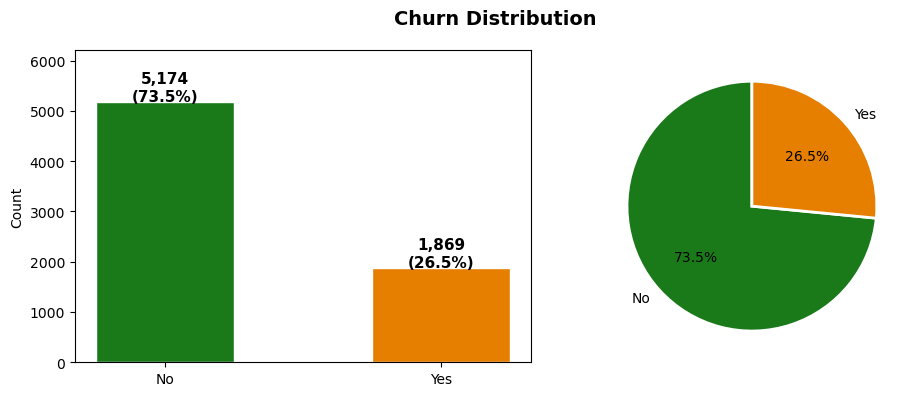

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Churn Distribution', fontsize=14, fontweight='bold')

colors = ['#1a7a1a', '#e67e00']

bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=colors, edgecolor='white', width=0.5)
for bar, (label, count) in zip(bars, churn_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 30,
                 f'{count:,}\n({churn_pct[label]:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))

plt.tight_layout()
plt.show()


Thus there is quite a big imbalance in the target value category which will be dealt with later. As only 26.5% of customers churned. This would entail that a Naive baseline model would have an accuracy rate of whatever the dominant class is. 

### Churn and Customer Demographics

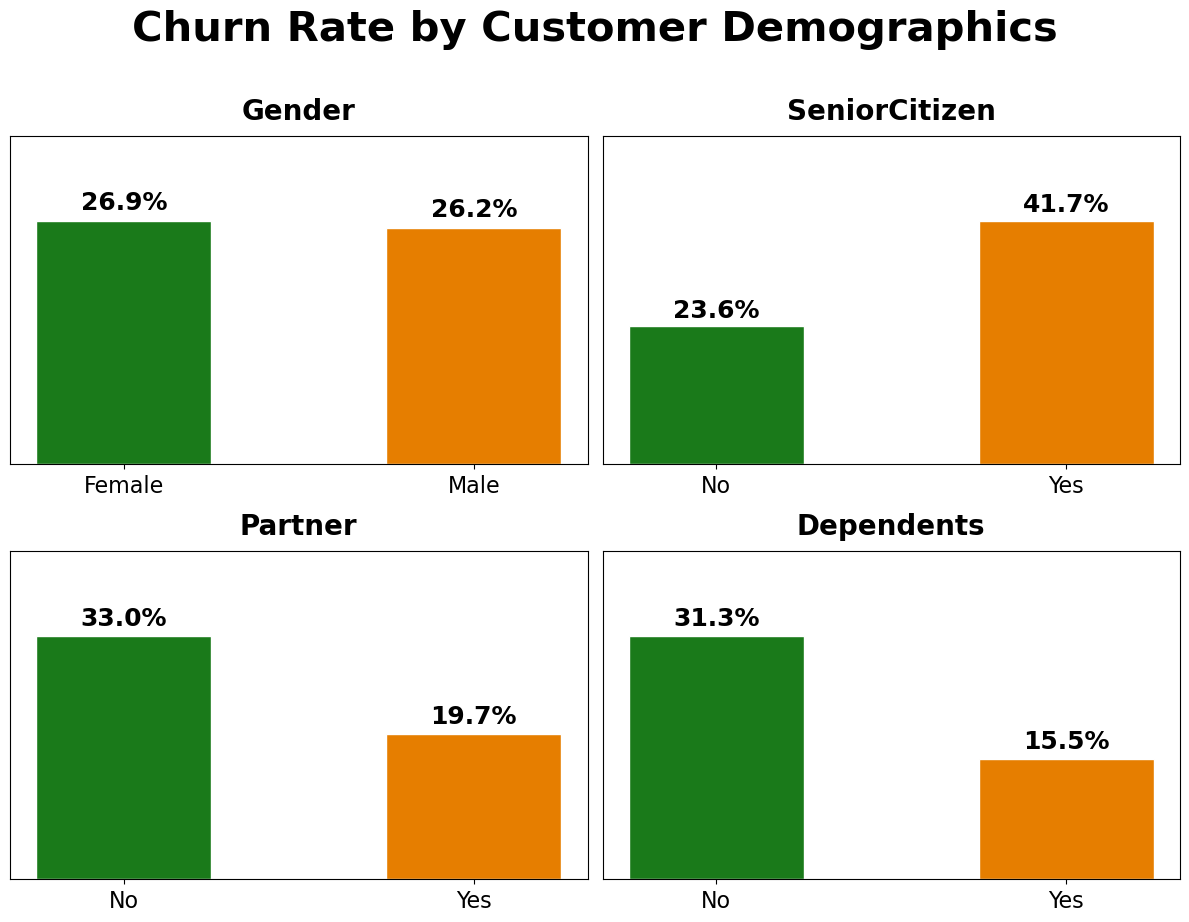

In [15]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
title_map = {'gender': 'Gender', 'SeniorCitizen': 'SeniorCitizen', 'Partner': 'Partner', 'Dependents': 'Dependents'}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Churn Rate by Customer Demographics', fontsize=30, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    plot_df = df.copy()
    if col == 'SeniorCitizen':
        plot_df[col] = plot_df[col].map({0: 'No', 1: 'Yes'})

    groups = plot_df.groupby(col)['Churn'].agg(
        ChurnRate=lambda x: (x == 'Yes').mean() * 100,
        Total='count'
    ).reset_index()

    bars = axes[i].bar(groups[col].astype(str), groups['ChurnRate'],
                       color=['#1a7a1a', '#e67e00'], edgecolor='white', width=0.5)

    for bar, (_, row) in zip(bars, groups.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.8,
                     f"{row['ChurnRate']:.1f}%",
                     ha='center', va='bottom', fontsize=18, fontweight='bold')

    axes[i].set_title(title_map[col], fontweight='bold', fontsize=20, pad=12)
    axes[i].set_ylabel('')
    axes[i].set_ylim(0, max(groups['ChurnRate']) * 1.35)
    axes[i].tick_params(axis='x', labelsize=16)
    axes[i].tick_params(axis='y', left=False, labelleft=False)

plt.tight_layout()
plt.show()


In [16]:
33 - 19.7

13.3

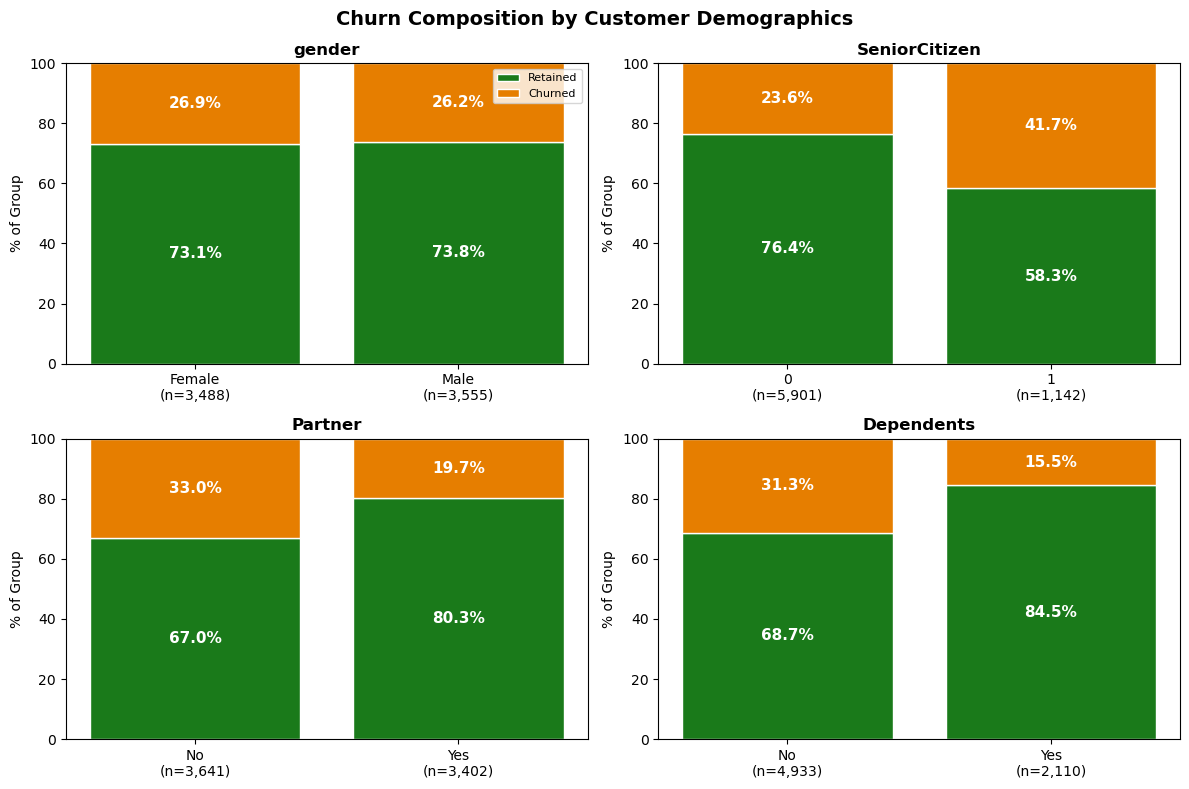

In [17]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Churn Composition by Customer Demographics', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    ct = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
    counts = df[col].value_counts()
    categories = ct.index.tolist()

    no_vals  = ct['No'].values
    yes_vals = ct['Yes'].values

    axes[i].bar(range(len(categories)), no_vals,  color='#1a7a1a', label='Retained', edgecolor='white')
    axes[i].bar(range(len(categories)), yes_vals, color='#e67e00', label='Churned',
                bottom=no_vals, edgecolor='white')

    for j, (no, yes) in enumerate(zip(no_vals, yes_vals)):
        axes[i].text(j, no / 2,       f'{no:.1f}%',  ha='center', va='center',
                     color='white', fontweight='bold', fontsize=11)
        axes[i].text(j, no + yes / 2, f'{yes:.1f}%', ha='center', va='center',
                     color='white', fontweight='bold', fontsize=11)

    axes[i].set_xticks(range(len(categories)))
    axes[i].set_xticklabels([f'{cat}\n(n={counts[cat]:,})' for cat in categories], fontsize=10)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('% of Group')
    axes[i].set_ylim(0, 100)
    if i == 0:
        axes[i].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


In [18]:
# Summary tables for each demographic feature
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    print(f'{col}')
    print(feature_summary(col).to_string(index=False))
    print()

gender
gender  Total  % of Dataset  Churned  Retained  Churn Rate (%)
Female   3488          49.5      939      2549            26.9
  Male   3555          50.5      930      2625            26.2

SeniorCitizen
 SeniorCitizen  Total  % of Dataset  Churned  Retained  Churn Rate (%)
             1   1142          16.2      476       666            41.7
             0   5901          83.8     1393      4508            23.6

Partner
Partner  Total  % of Dataset  Churned  Retained  Churn Rate (%)
     No   3641          51.7     1200      2441            33.0
    Yes   3402          48.3      669      2733            19.7

Dependents
Dependents  Total  % of Dataset  Churned  Retained  Churn Rate (%)
        No   4933          70.0     1543      3390            31.3
       Yes   2110          30.0      326      1784            15.5



Gender doesn't have a lot of effect on churn as males and females seem to churn at nearly the same rate. Additionally, the dataset seems to be qutie well balanced between Male and Female 

Senior citizens seem to churn at roughly double the overall average 41.7 % vs 26.5%, thus this could be a focus point for the business to understand what could driving this  

Customers without a partner or dependents churn at higher rates which suggests that household stability might correlate with retention rates

### Churn by Account Information 

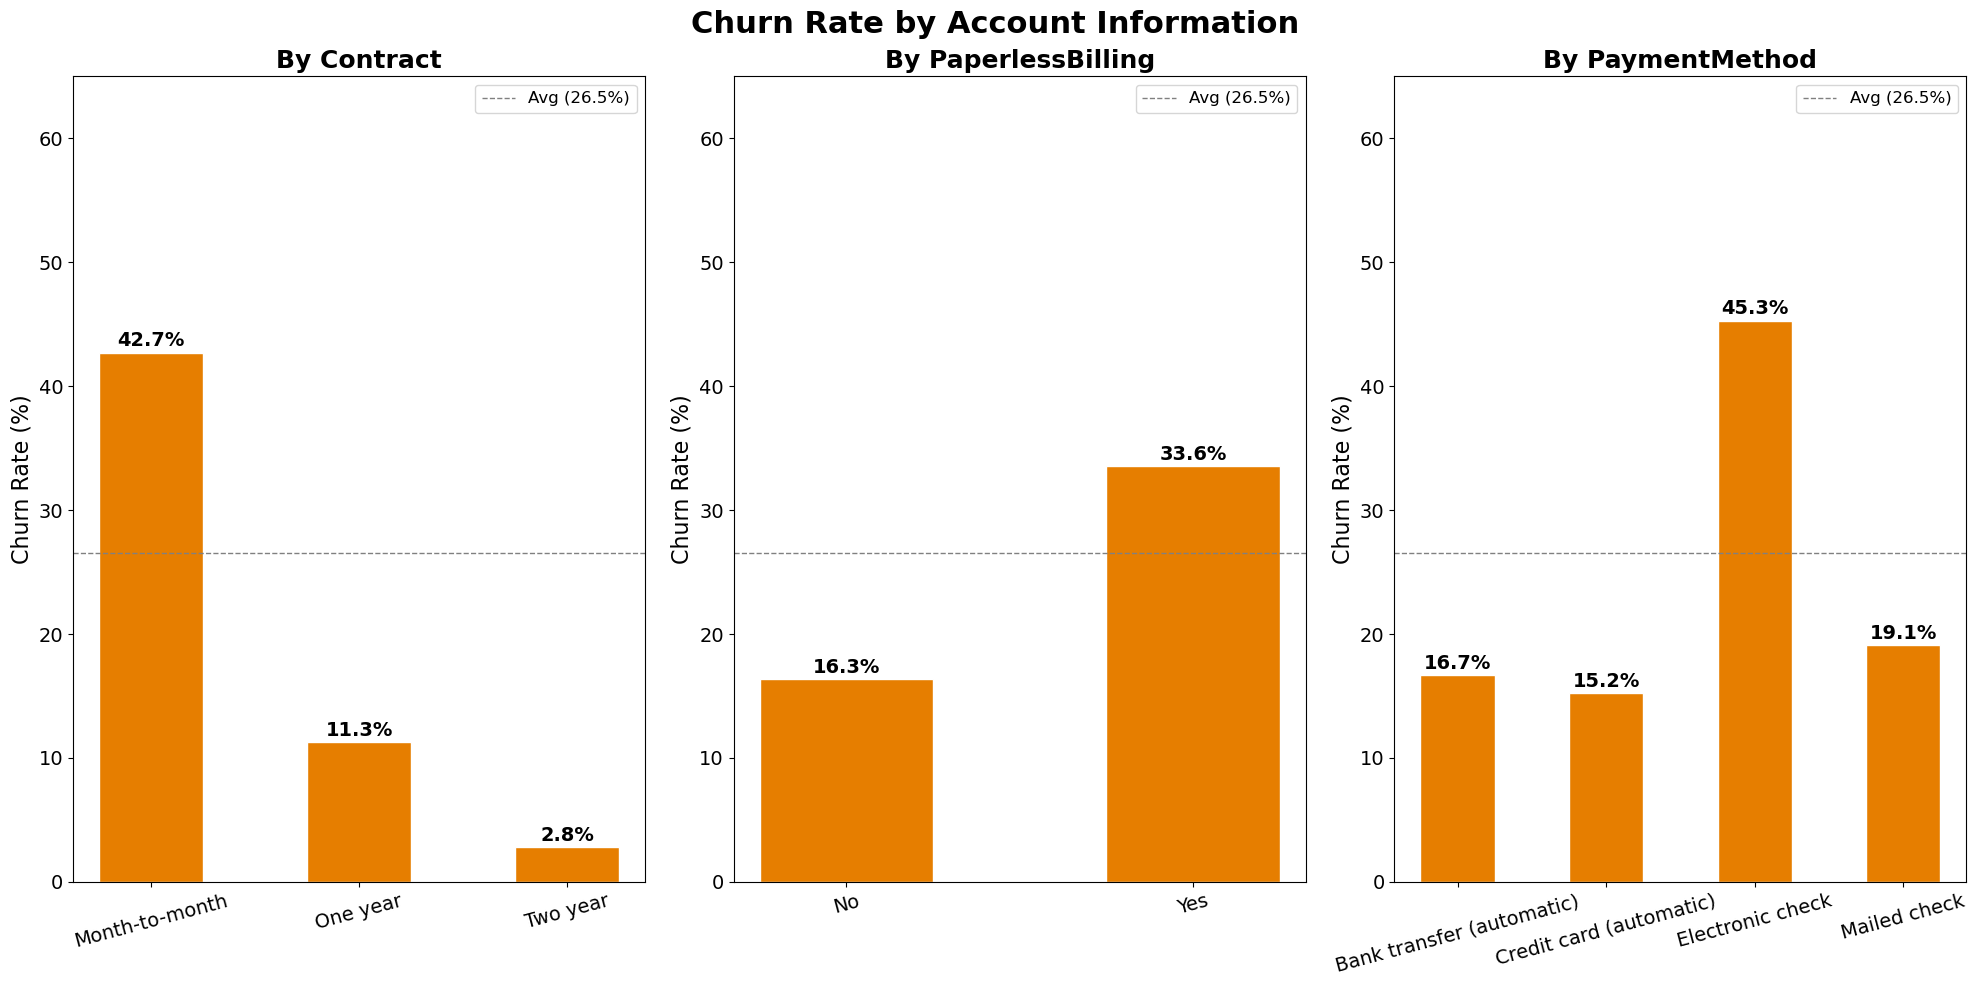

In [19]:
overall_churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100

account_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle('Churn Rate by Account Information', fontsize=22, fontweight='bold')

for ax, col in zip(axes, account_cols):
    cr = churn_rate_by(col)
    bars = ax.bar(cr[col].astype(str), cr['ChurnRate'],
                  color='#e67e00', edgecolor='white', width=0.5)
    for bar, rate in zip(bars, cr['ChurnRate']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', fontsize=14, fontweight='bold')
    ax.axhline(overall_churn_rate, color='grey', linestyle='--', linewidth=1,
               label=f'Avg ({overall_churn_rate:.1f}%)')
    ax.set_title(f'By {col}', fontsize=18, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)', fontsize=16)
    ax.set_ylim(0, 65)
    ax.tick_params(axis='x', rotation=15, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

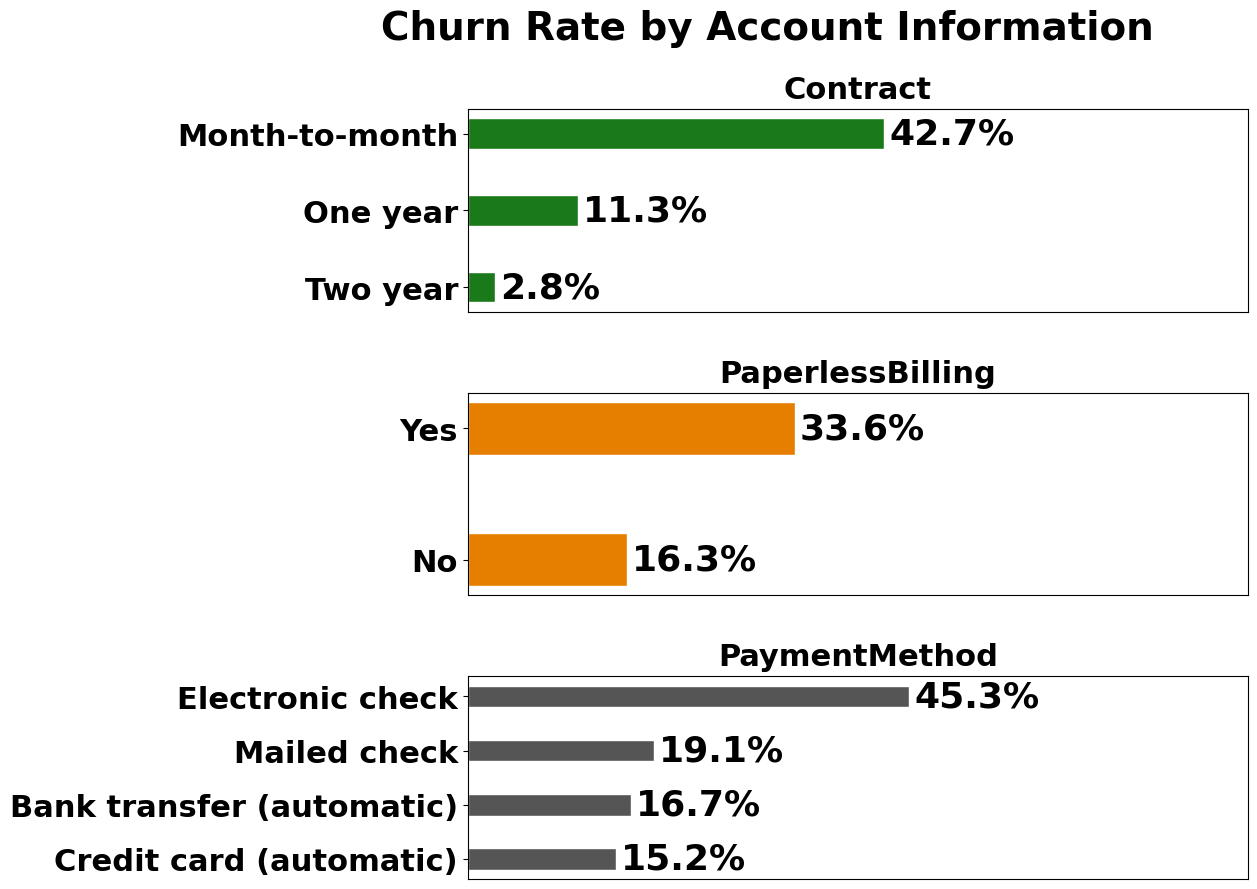

In [20]:
account_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']
graph_colors = ['#1a7a1a', '#e67e00', '#555555']
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Churn Rate by Account Information', fontsize=28, fontweight='bold')
plt.subplots_adjust(hspace=0.4, left=0.25, right=0.9)
for ax, col, color in zip(axes, account_cols, graph_colors):
    cr = churn_rate_by(col).sort_values('ChurnRate', ascending=True)
    positions = range(len(cr))
    bars = ax.barh(positions, cr['ChurnRate'],
                   color=color, edgecolor='white', height=0.4)
    ax.set_yticks(positions)
    ax.set_yticklabels(cr[col].astype(str), fontsize=22, fontweight='bold')
    for bar, rate in zip(bars, cr['ChurnRate']):
        ax.text(bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f'{rate:.1f}%', va='center', fontsize=26, fontweight='bold')
    ax.set_title(col, fontsize=22, fontweight='bold', pad=8)
    ax.set_xlim(0, 80)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', labelbottom=False, bottom=False)
    ax.set_xlabel('')
plt.show()


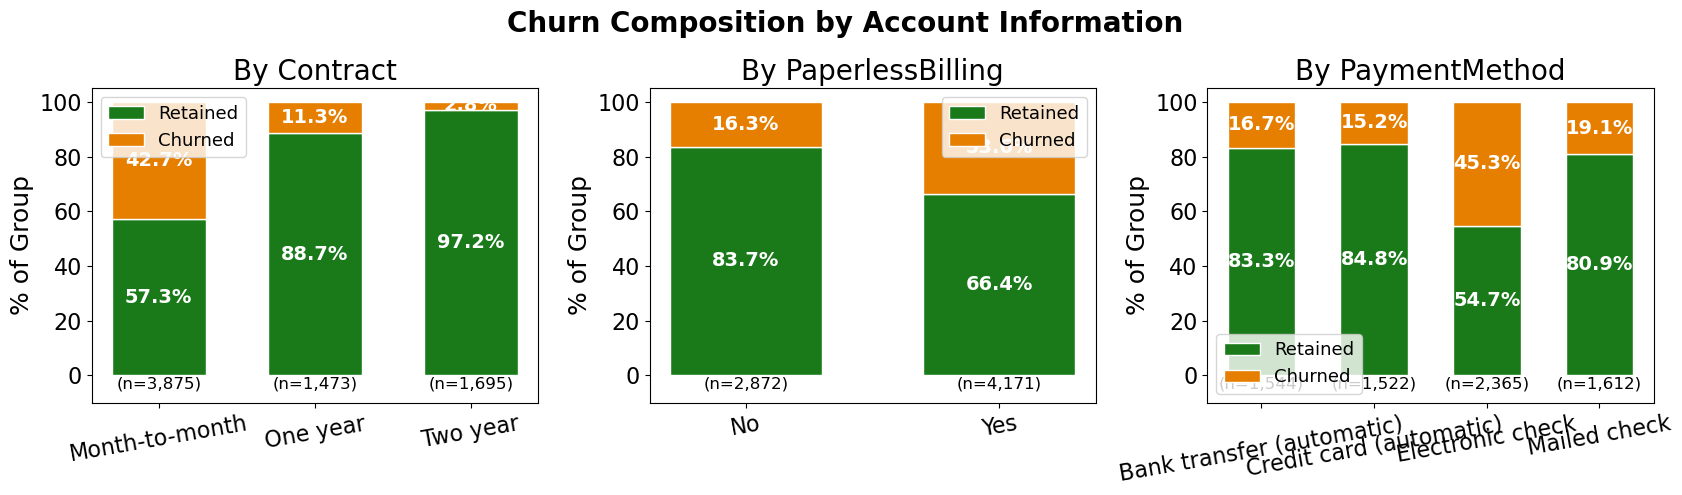

In [21]:
# Stacked bar showing full group composition (retained + churned)
def stacked_churn_bars(ax, col, title=None):
    ct     = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
    counts = df[col].value_counts()
    cats   = ct.index.tolist()
    no_vals  = ct['No'].values
    yes_vals = ct['Yes'].values
    x = range(len(cats))
    ax.bar(x, no_vals,  color='#1a7a1a', label='Retained', edgecolor='white', width=0.6)
    ax.bar(x, yes_vals, color='#e67e00', label='Churned',  edgecolor='white', width=0.6,
           bottom=no_vals)
    for j, (cat, n_pct, y_pct) in enumerate(zip(cats, no_vals, yes_vals)):
        ax.text(j, n_pct / 2,         f'{n_pct:.1f}%', ha='center', va='center',
                fontsize=14, color='white', fontweight='bold')
        ax.text(j, n_pct + y_pct / 2, f'{y_pct:.1f}%', ha='center', va='center',
                fontsize=14, color='white', fontweight='bold')
        ax.text(j, -5, f'(n={counts[cat]:,})', ha='center', fontsize=12, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cats])
    ax.set_ylim(-10, 105)
    ax.set_ylabel('% of Group', fontsize=18)
    ax.set_title(title or f'By {col}', fontsize=20)
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(fontsize=13)

account_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Churn Composition by Account Information', fontsize=20, fontweight='bold')

for ax, col in zip(axes, account_cols):
    stacked_churn_bars(ax, col)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()


In [22]:
for col in ['Contract', 'PaperlessBilling', 'PaymentMethod']:
    print(f'{col}')
    print(feature_summary(col).to_string(index=False))
    print()

Contract
      Contract  Total  % of Dataset  Churned  Retained  Churn Rate (%)
Month-to-month   3875          55.0     1655      2220            42.7
      One year   1473          20.9      166      1307            11.3
      Two year   1695          24.1       48      1647             2.8

PaperlessBilling
PaperlessBilling  Total  % of Dataset  Churned  Retained  Churn Rate (%)
             Yes   4171          59.2     1400      2771            33.6
              No   2872          40.8      469      2403            16.3

PaymentMethod
            PaymentMethod  Total  % of Dataset  Churned  Retained  Churn Rate (%)
         Electronic check   2365          33.6     1071      1294            45.3
             Mailed check   1612          22.9      308      1304            19.1
Bank transfer (automatic)   1544          21.9      258      1286            16.7
  Credit card (automatic)   1522          21.6      232      1290            15.2



Contract type seems to be a strong predictor of chrun rate, with month-to-month contract having the highest churn rate at 42.7% compared to 11.3% for One year and 2.8% for two year contracts. This points to switching costs being a dominant driver of churn.

Paperless billings seems to be associated with higher churn, this might indicate that more digital customers are also the ones that are more sensitive to other other market competitors'offers.

Electronic check payment is associated with 45.3% churn which is far above other automatic payment methods which hover around 15 to 17% and mailed check at 19.1%. 

### Churn by Services

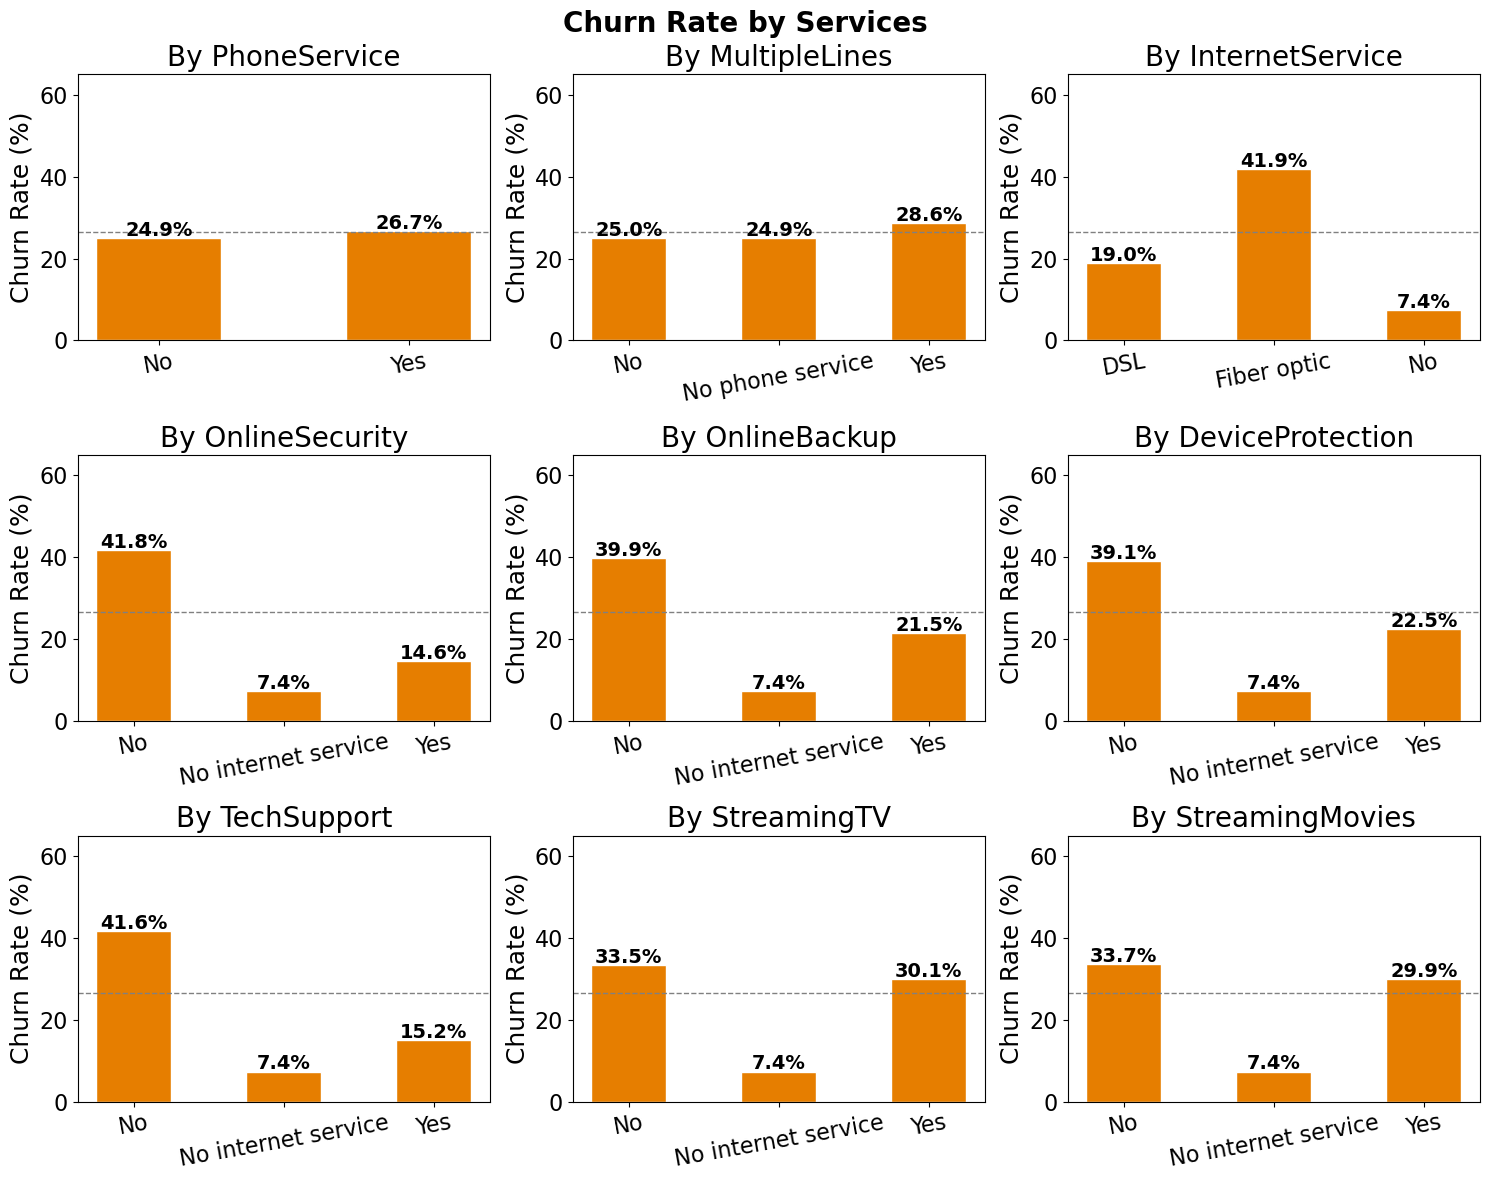

In [23]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Churn Rate by Services', fontsize=20, fontweight='bold')

for ax, col in zip(axes.flatten(), service_cols):
    cr = churn_rate_by(col)
    bars = ax.bar(cr[col].astype(str), cr['ChurnRate'],
                  color='#e67e00', edgecolor='white', width=0.5)
    for bar, rate in zip(bars, cr['ChurnRate']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', fontsize=14, fontweight='bold')
    ax.axhline(overall_churn_rate, color='grey', linestyle='--', linewidth=1)
    ax.set_title(f'By {col}', fontsize=20)
    ax.set_ylabel('Churn Rate (%)', fontsize=18)
    ax.set_ylim(0, 65)
    ax.tick_params(axis='both', labelsize=16)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()


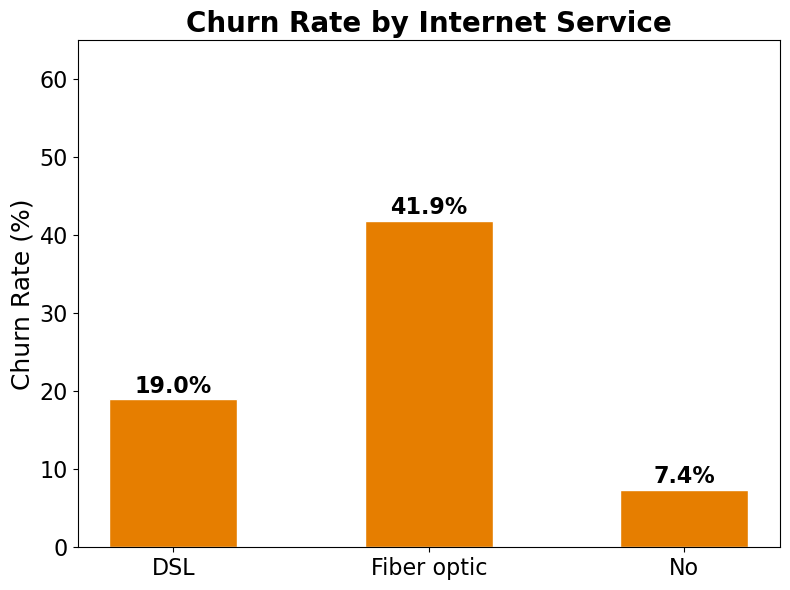

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

cr = churn_rate_by('InternetService')
bars = ax.bar(cr['InternetService'].astype(str), cr['ChurnRate'],
              color='#e67e00', edgecolor='white', width=0.5)
for bar, rate in zip(bars, cr['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{rate:.1f}%', ha='center', fontsize=16, fontweight='bold')
ax.set_title('Churn Rate by Internet Service', fontsize=20, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=18)
ax.set_ylim(0, 65)
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()


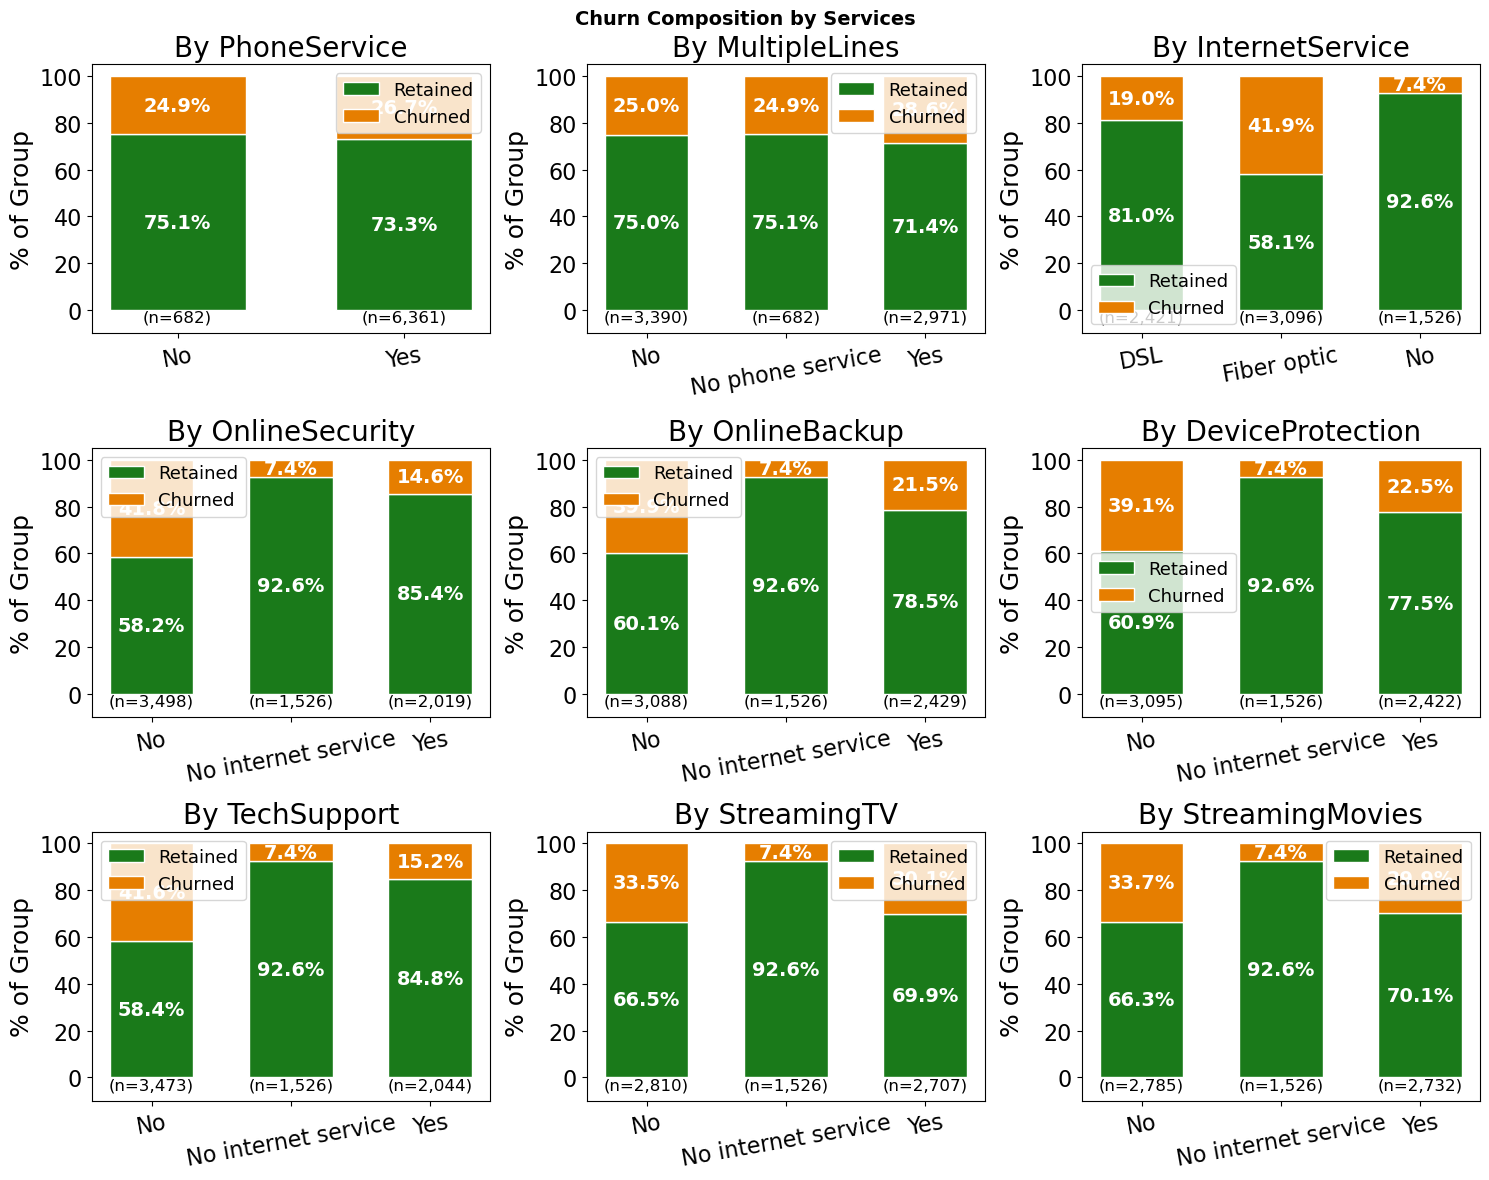

In [25]:
#Or this stacked bar for more info
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Churn Composition by Services', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), service_cols):
    stacked_churn_bars(ax, col)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

In [26]:
for col in service_cols:
    print(f' {col} ')
    print(feature_summary(col).to_string(index=False))
    print()

 PhoneService 
PhoneService  Total  % of Dataset  Churned  Retained  Churn Rate (%)
         Yes   6361          90.3     1699      4662            26.7
          No    682           9.7      170       512            24.9

 MultipleLines 
   MultipleLines  Total  % of Dataset  Churned  Retained  Churn Rate (%)
             Yes   2971          42.2      850      2121            28.6
              No   3390          48.1      849      2541            25.0
No phone service    682           9.7      170       512            24.9

 InternetService 
InternetService  Total  % of Dataset  Churned  Retained  Churn Rate (%)
    Fiber optic   3096          44.0     1297      1799            41.9
            DSL   2421          34.4      459      1962            19.0
             No   1526          21.7      113      1413             7.4

 OnlineSecurity 
     OnlineSecurity  Total  % of Dataset  Churned  Retained  Churn Rate (%)
                 No   3498          49.7     1461      2037         

Fiber optic internet has by far the highest churn rate (41.9%) compared to DSL (19%) and no internet (7.4%). Fiber customers might face more competitive alternatives or have higher price sensitivity.

Online Security, Tech Support, and Device Protection all show a clear protective effect as customers without these add-ons churn at roughly double the rate of those with them, suggesting these services increase switching costs. The same could be said for Online Backup but at a lower rate. 

Streaming TV, Movies, Multiple lines and Phone Service show no meaningful differentiation churn rates are near-identical across subscription status, so these features likely carry little predictive weight.

## Numeric Features and Churn

We will plot KDE (Kernel Density Evaluation) which are quasi smoothed out version of histograms to evaluate how if Churn = Yes or Churn = No might be different when evaluating it against different numerical features.  


/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/563902182.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df,
/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/563902182.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(['Retained', 'Churned'])
/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/563902182.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df,
/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/563902182.py:19: UserWarning: set_ticklabels() should only be u

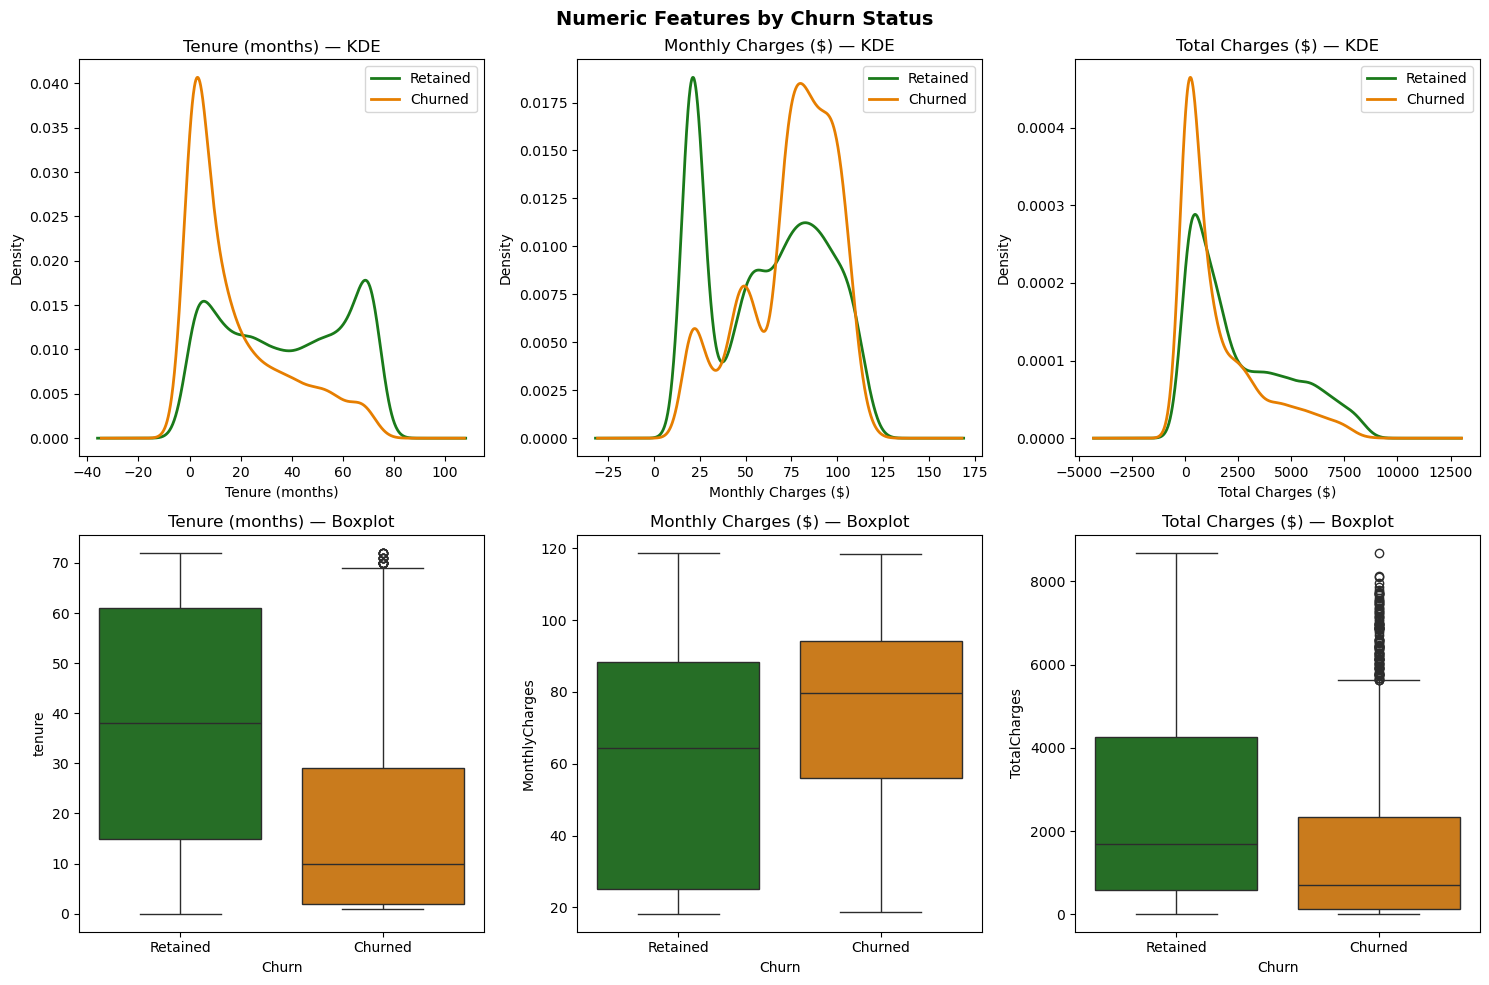

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Numeric Features by Churn Status', fontsize=14, fontweight='bold')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
labels   = ['Tenure (months)', 'Monthly Charges ($)', 'Total Charges ($)']

for i, (col, label) in enumerate(zip(num_cols, labels)):
    for val, lbl, clr in [('No', 'Retained', '#1a7a1a'), ('Yes', 'Churned', '#e67e00')]:
        df[df['Churn'] == val][col].dropna().plot.kde(
            ax=axes[0, i], label=lbl, color=clr, linewidth=2
        )
    axes[0, i].set_title(f'{label} — KDE')
    axes[0, i].set_xlabel(label)
    axes[0, i].legend()

    sns.boxplot(x='Churn', y=col, data=df,
                palette=['#1a7a1a', '#e67e00'], ax=axes[1, i])
    axes[1, i].set_title(f'{label} — Boxplot')
    axes[1, i].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()


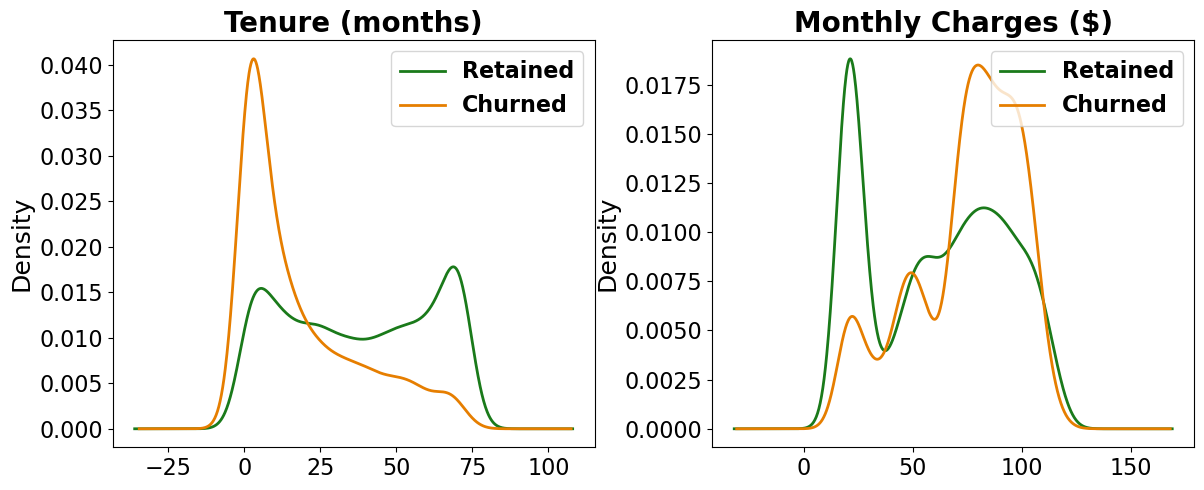

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

num_cols = ['tenure', 'MonthlyCharges']
labels   = ['Tenure (months)', 'Monthly Charges ($)']
legend_locs = ['upper right', 'upper right']

for i, (col, label) in enumerate(zip(num_cols, labels)):
    for val, lbl, clr in [('No', 'Retained', '#1a7a1a'), ('Yes', 'Churned', '#e67e00')]:
        df[df['Churn'] == val][col].dropna().plot.kde(
            ax=axes[i], label=lbl, color=clr, linewidth=2
        )
    axes[i].set_title(label, fontsize=20, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density', fontsize=18)
    axes[i].tick_params(axis='both', labelsize=16)
    legend = axes[i].legend(fontsize=16, loc=legend_locs[i])
    for text in legend.get_texts():
        text.set_fontweight('bold')

plt.tight_layout()
plt.show()


/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/3060894656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/3060894656.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Retained', 'Churned'], fontsize=16, fontweight='bold')
/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/3060894656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/md/bvpb41394w5fz9pd9h30qf0m0000gn/T/ipykernel_3583/3060894656.py:17: UserWarning: set_ticklabels() should only be used with a fixe

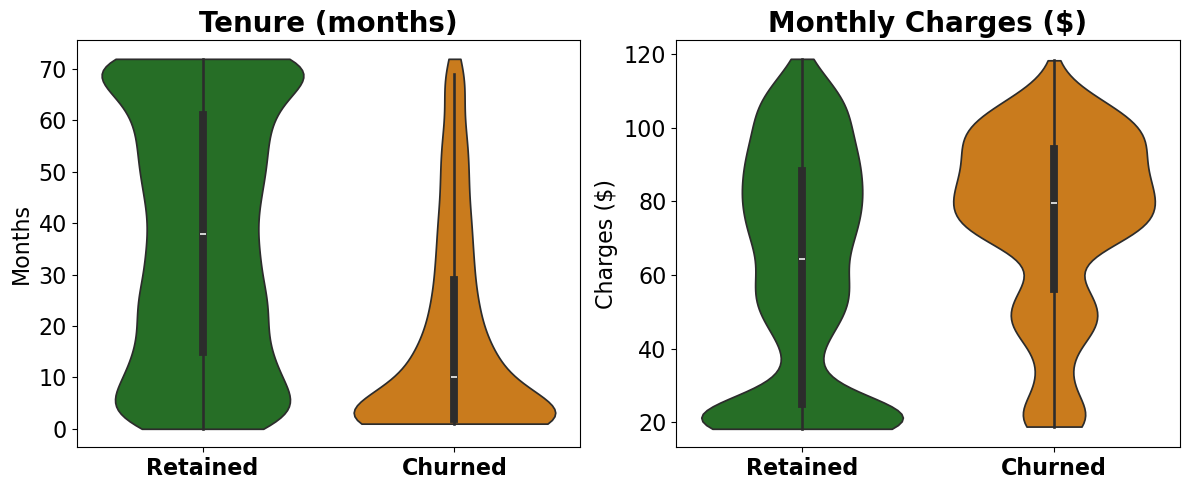

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

num_cols = ['tenure', 'MonthlyCharges']
labels = ['Tenure (months)', 'Monthly Charges ($)']
ylabels = ['Months', 'Charges ($)']

for i, (col, label, ylabel) in enumerate(zip(num_cols, labels, ylabels)):
    sns.violinplot(
        data=df, x='Churn', y=col, ax=axes[i],
        palette={'No': '#1a7a1a', 'Yes': '#e67e00'},
        inner='box',
        cut=0
    )
    axes[i].set_title(label, fontsize=20, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(ylabel, fontsize=16)
    axes[i].set_xticklabels(['Retained', 'Churned'], fontsize=16, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()


In [30]:
# Numeric summary table: mean and median by churn status
num_summary = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].agg(
    ['mean', 'median']
).round(1)
num_summary.index = ['Retained', 'Churned']
print(num_summary)

         tenure        MonthlyCharges        TotalCharges        
           mean median           mean median         mean  median
Retained   37.6   38.0           61.3   64.4       2555.3  1683.6
Churned    18.0   10.0           74.4   79.6       1531.8   703.6


For Monthly Charges, it seems that churned customers tend to pay a higher median than the non churned ones.

Tenure seems to be a clear metric to predict customer churn behvior with chruned customers having a lower tenure than retained ones. It seems like a hugh amoutn of customers churn within the first 20 months thus pointing to a crtiical window in which customer retention is crucial

Tenure is the clearest numeric separator: churned customers have a median tenure of around 10 months vs 38 months for retained customers.


It is difficult to discern any relevant findings from the Total Charges KDE 

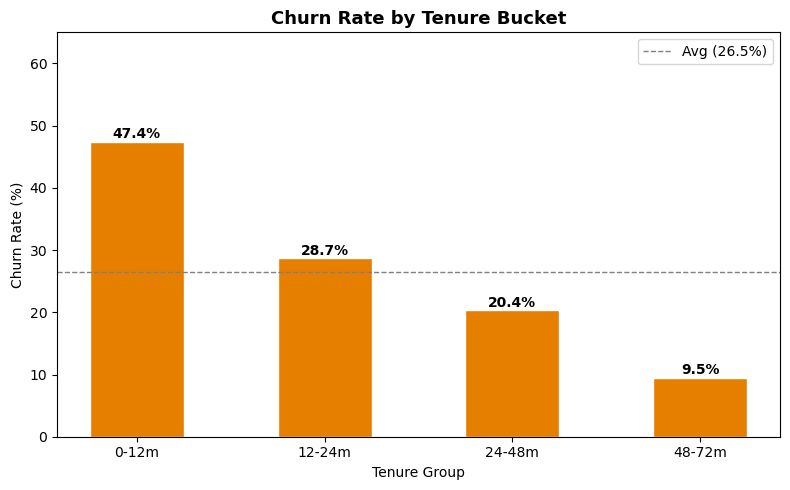

In [31]:
df['tenure_bin'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 48, 72],
                           labels=['0-12m', '12-24m', '24-48m', '48-72m'],
                           include_lowest=True)

cr = df.groupby('tenure_bin', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index(name='ChurnRate')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cr['tenure_bin'].astype(str), cr['ChurnRate'],
              color='#e67e00', edgecolor='white', width=0.5)
for bar, rate in zip(bars, cr['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(overall_churn_rate, color='grey', linestyle='--', linewidth=1,
           label=f'Avg ({overall_churn_rate:.1f}%)')
ax.set_title('Churn Rate by Tenure Bucket', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 65)
ax.legend()
plt.tight_layout()
plt.show()


Nearly half (47.7%) of customers churn within their first 12 months thus the critical retention window is early tenure. Churn drops sharply as customers pass the two-year mark.

### Total Services
We engineer one composite feature which counts the eight binary services a customer subscribed to and captures the depth of the customer's relationship in a single number

In [32]:
binary_services = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['totalservices'] = df[binary_services].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)

print('Total services distribution:')
print(df['totalservices'].value_counts().sort_index().to_string())

Total services distribution:
totalservices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208


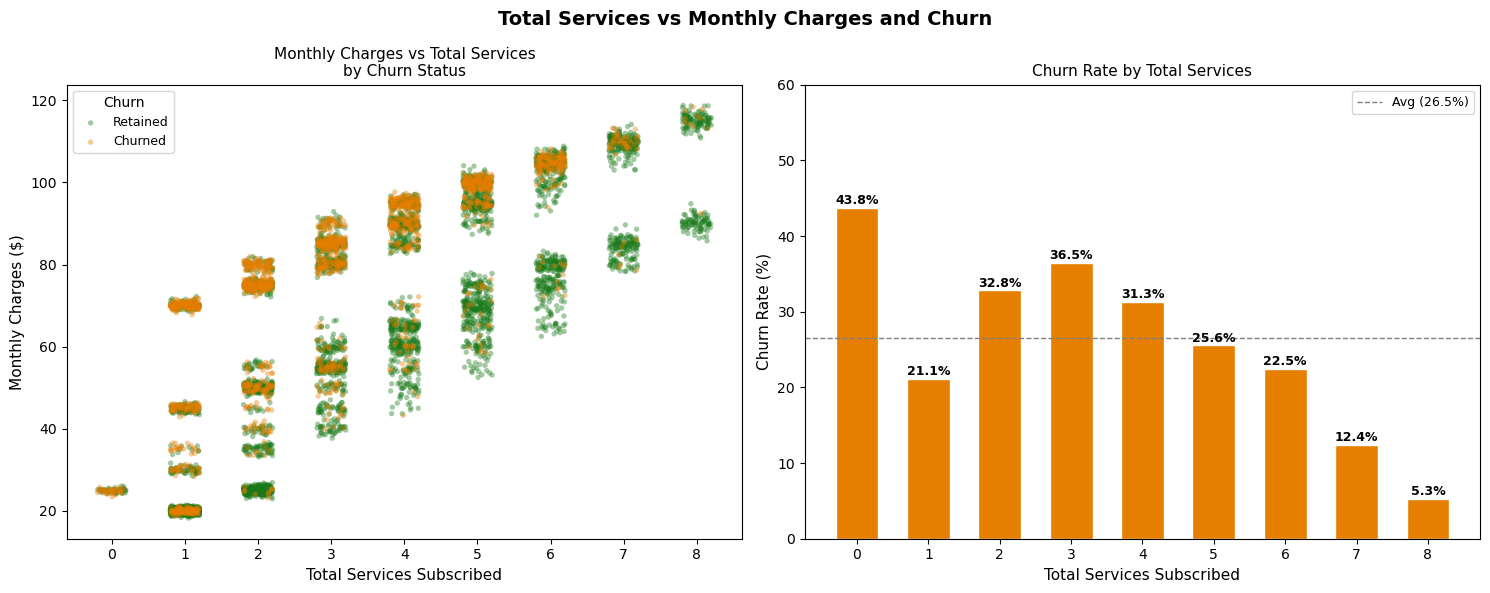

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Total Services vs Monthly Charges and Churn', fontsize=14, fontweight='bold')

for churn_val, label, color in [('No', 'Retained', '#1a7a1a'), ('Yes', 'Churned', '#e67e00')]:
    subset = df[df['Churn'] == churn_val]
    jitter = np.random.RandomState(42).uniform(-0.2, 0.2, len(subset))
    axes[0].scatter(
        subset['totalservices'] + jitter,
        subset['MonthlyCharges'],
        c=color, label=label, alpha=0.4, s=15, edgecolors='none'
    )
axes[0].set_xlabel('Total Services Subscribed', fontsize=11)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=11)
axes[0].set_title('Monthly Charges vs Total Services\nby Churn Status', fontsize=11)
axes[0].set_xticks(range(9))
axes[0].legend(title='Churn', fontsize=9)

cr = df.groupby('totalservices')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index(name='ChurnRate')

bars = axes[1].bar(cr['totalservices'], cr['ChurnRate'],
                   color='#e67e00', edgecolor='white', width=0.6)
for bar, rate in zip(bars, cr['ChurnRate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(overall_churn_rate, color='grey', linestyle='--', linewidth=1,
                label=f'Avg ({overall_churn_rate:.1f}%)')
axes[1].set_xlabel('Total Services Subscribed', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_title('Churn Rate by Total Services', fontsize=11)
axes[1].set_xticks(range(9))
axes[1].set_ylim(0, 60)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


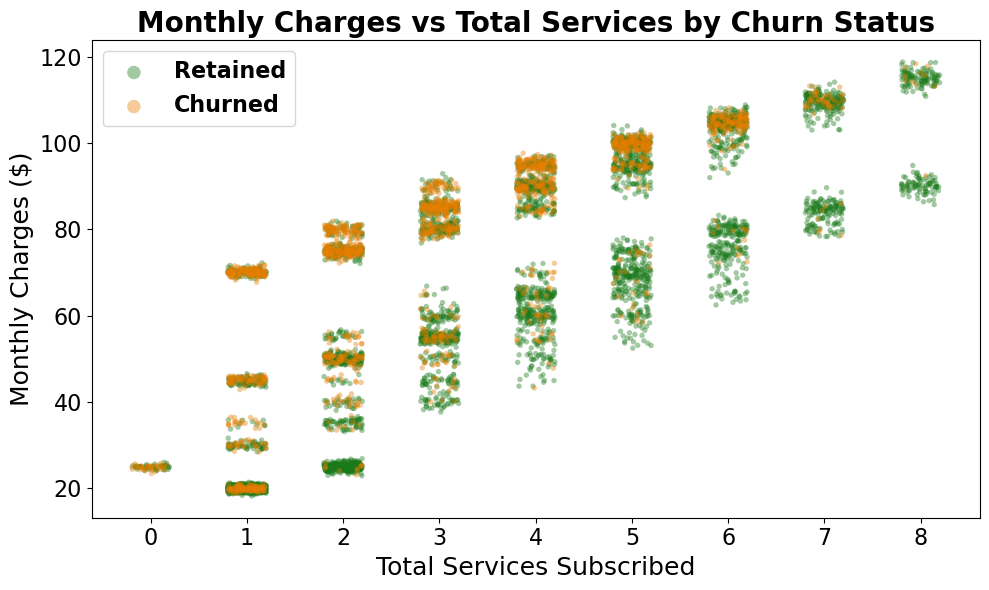

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

for churn_val, label, color in [('No', 'Retained', '#1a7a1a'), ('Yes', 'Churned', '#e67e00')]:
    subset = df[df['Churn'] == churn_val]
    jitter = np.random.RandomState(42).uniform(-0.2, 0.2, len(subset))
    ax.scatter(
        subset['totalservices'] + jitter,
        subset['MonthlyCharges'],
        c=color, label=label, alpha=0.4, s=15, edgecolors='none'
    )

ax.set_xlabel('Total Services Subscribed', fontsize=18)
ax.set_ylabel('Monthly Charges ($)', fontsize=18)
ax.set_title('Monthly Charges vs Total Services by Churn Status', fontsize=20, fontweight='bold')
ax.set_xticks(range(9))
ax.tick_params(axis='both', labelsize=16)
legend = ax.legend(fontsize=16, markerscale=2.5)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()


In [35]:
# Summary table for totalservices
ts_summary = df.groupby('totalservices')['Churn'].agg(
    Total='count',
    Churned=lambda x: (x == 'Yes').sum(),
    Retained=lambda x: (x == 'No').sum(),
    ChurnRate=lambda x: round((x == 'Yes').mean() * 100, 1)
).reset_index().rename(columns={'ChurnRate': 'Churn Rate (%)'})
ts_summary['% of Dataset'] = (ts_summary['Total'] / ts_summary['Total'].sum() * 100).round(1)
print(ts_summary[['totalservices','Total','% of Dataset','Churned','Retained','Churn Rate (%)']].to_string(index=False))

 totalservices  Total  % of Dataset  Churned  Retained  Churn Rate (%)
             0     80           1.1       35        45            43.8
             1   1701          24.2      359      1342            21.1
             2   1188          16.9      390       798            32.8
             3    965          13.7      352       613            36.5
             4    922          13.1      289       633            31.3
             5    908          12.9      232       676            25.6
             6    676           9.6      152       524            22.5
             7    395           5.6       49       346            12.4
             8    208           3.0       11       197             5.3


Churned customers concentrate at low service count but high monthly charges and the trend seems to be downwards slopping aside from an uptick from 1 to 3. Customers with 8 services chrun at just 5.3% vs 36.5% at 2 services 

### Correlation Analysis 

In [36]:
from sklearn.preprocessing import LabelEncoder

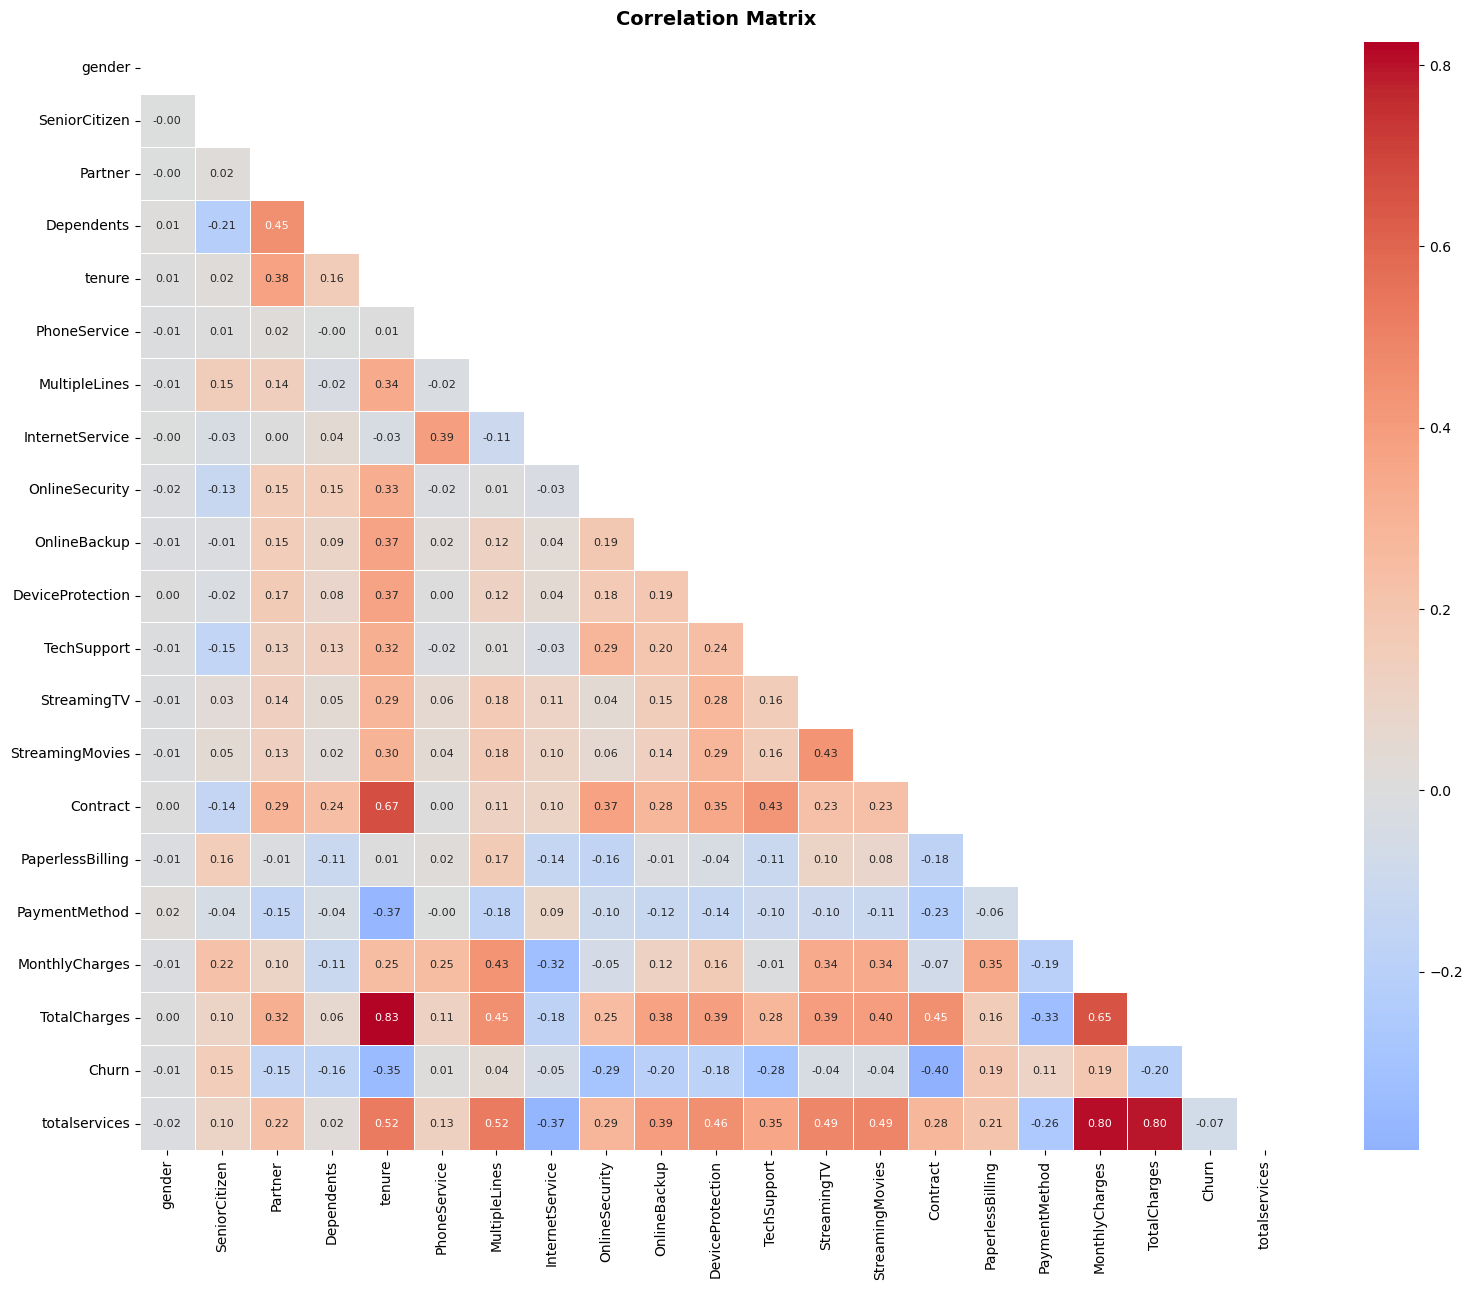

In [37]:
# Label-encode for correlation — purely for this visualisation, not for modelling
df_corr = df.drop(columns=['customerID', 'tenure_bin']).copy()
df_corr['Churn'] = (df_corr['Churn'] == 'Yes').astype(int)

#We included this Encoder in order to look at correlations among non-numerical features
le = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

For illustrative purposes we will also breakdown churn vs numerical and churn vs non-numerical 


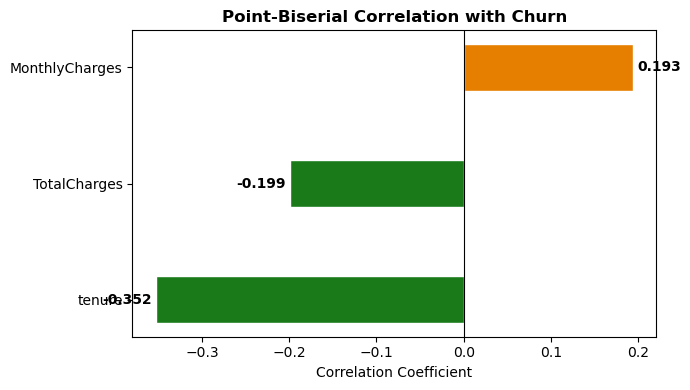

In [38]:
churn_binary = (df['Churn'] == 'Yes').astype(int)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

pb_corr = df[num_cols].apply(lambda col: col.corr(churn_binary)).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#e67e00' if v > 0 else '#1a7a1a' for v in pb_corr.values]
bars = ax.barh(pb_corr.index, pb_corr.values, color=colors, edgecolor='white', height=0.4)

for bar, val in zip(bars, pb_corr.values):
    ax.text(val + (0.005 if val > 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Point-Biserial Correlation with Churn', fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


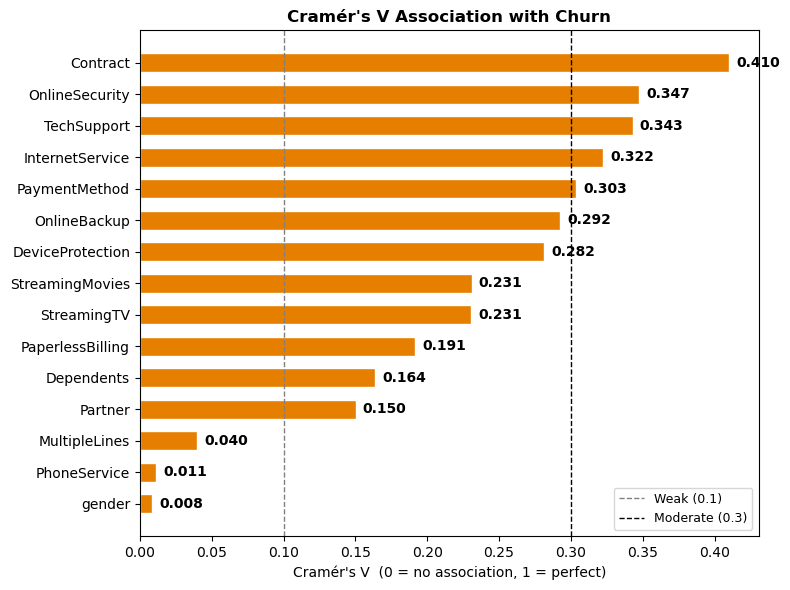

In [39]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = [c for c in df.select_dtypes('object').columns
            if c not in ['Churn', 'customerID']]

cv_scores = pd.Series(
    {col: cramers_v(df[col], df['Churn']) for col in cat_cols}
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(cv_scores.index, cv_scores.values, color='#e67e00', edgecolor='white', height=0.6)

for bar, val in zip(bars, cv_scores.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontweight='bold')

ax.axvline(0.1, color='grey', linestyle='--', linewidth=1, label='Weak (0.1)')
ax.axvline(0.3, color='black', linestyle='--', linewidth=1, label='Moderate (0.3)')
ax.set_title("Cramér's V Association with Churn", fontweight='bold')
ax.set_xlabel("Cramér's V  (0 = no association, 1 = perfect)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


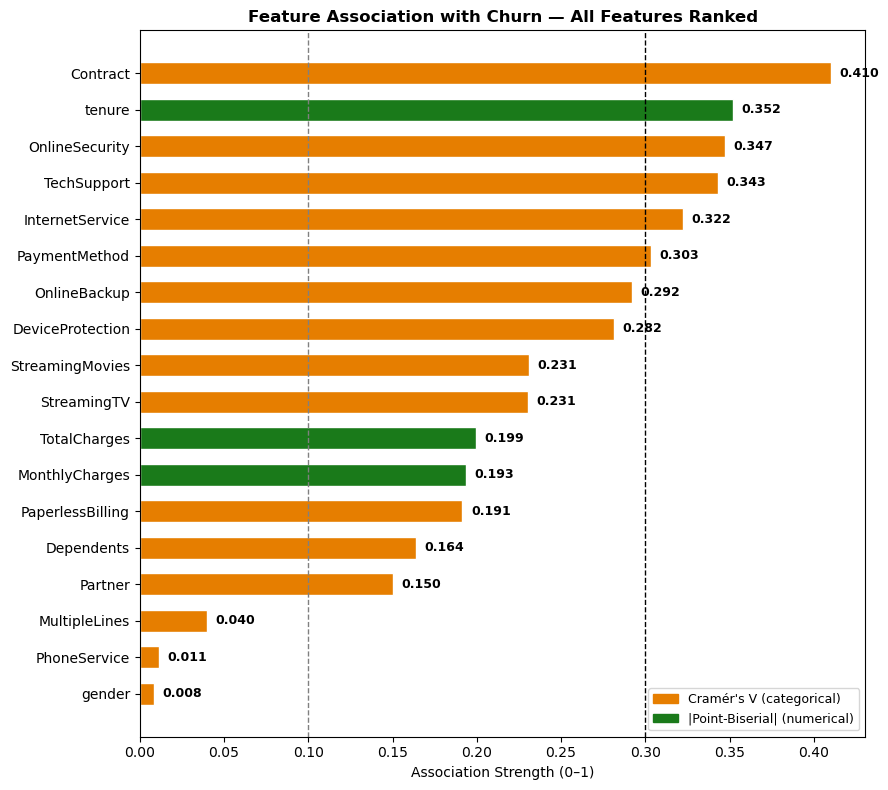

In [40]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

churn_binary = (df['Churn'] == 'Yes').astype(int)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df.select_dtypes('object').columns
            if c not in ['Churn', 'customerID']]

# For categorical variables we use Cramer V
cat_scores = {col: (cramers_v(df[col], df['Churn']), "Cramér's V") for col in cat_cols}

# For numerical variables, point-biserial as an absolute value is calculated and outputs a value between 0 and 1
num_scores = {col: (abs(df[col].corr(churn_binary)), '|Point-Biserial|') for col in num_cols}

all_scores = pd.DataFrame(
    [(col, score, method) for col, (score, method) in {**cat_scores, **num_scores}.items()],
    columns=['Feature', 'Score', 'Method']
).sort_values('Score', ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#1a7a1a' if m == '|Point-Biserial|' else '#e67e00'
          for m in all_scores['Method']]

bars = ax.barh(all_scores['Feature'], all_scores['Score'],
               color=colors, edgecolor='white', height=0.6)

for bar, (_, row) in zip(bars, all_scores.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{row['Score']:.3f}", va='center', fontweight='bold', fontsize=9)

ax.axvline(0.1, color='grey', linestyle='--', linewidth=1, label='Weak (0.1)')
ax.axvline(0.3, color='black', linestyle='--', linewidth=1, label='Moderate (0.3)')

from matplotlib.patches import Patch
legend_elements = [Patch(color='#e67e00', label="Cramér's V (categorical)"),
                   Patch(color='#1a7a1a', label='|Point-Biserial| (numerical)')]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_title('Feature Association with Churn — All Features Ranked', fontweight='bold')
ax.set_xlabel('Association Strength (0–1)')
plt.tight_layout()
plt.show()


This large correlation matrix highlights several things such as the uselessness of Gender which has a low correlation with everything and should be dropped. Paperless Billing is also quite low with everything. The high correlation between Tenue and Total Charges at 0.83 is worrying considering that we might face a multicolineratiy issue if we keep it 
Finally, Tenue seems to be the feature that is most highly negatively correlated with churn, the longer someone stays the less likely they are to churn


In [41]:
binary_services = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['totalservices'] = df[binary_services].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)

print('Total services distribution:')
print(df['totalservices'].value_counts().sort_index().to_string())

Total services distribution:
totalservices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208


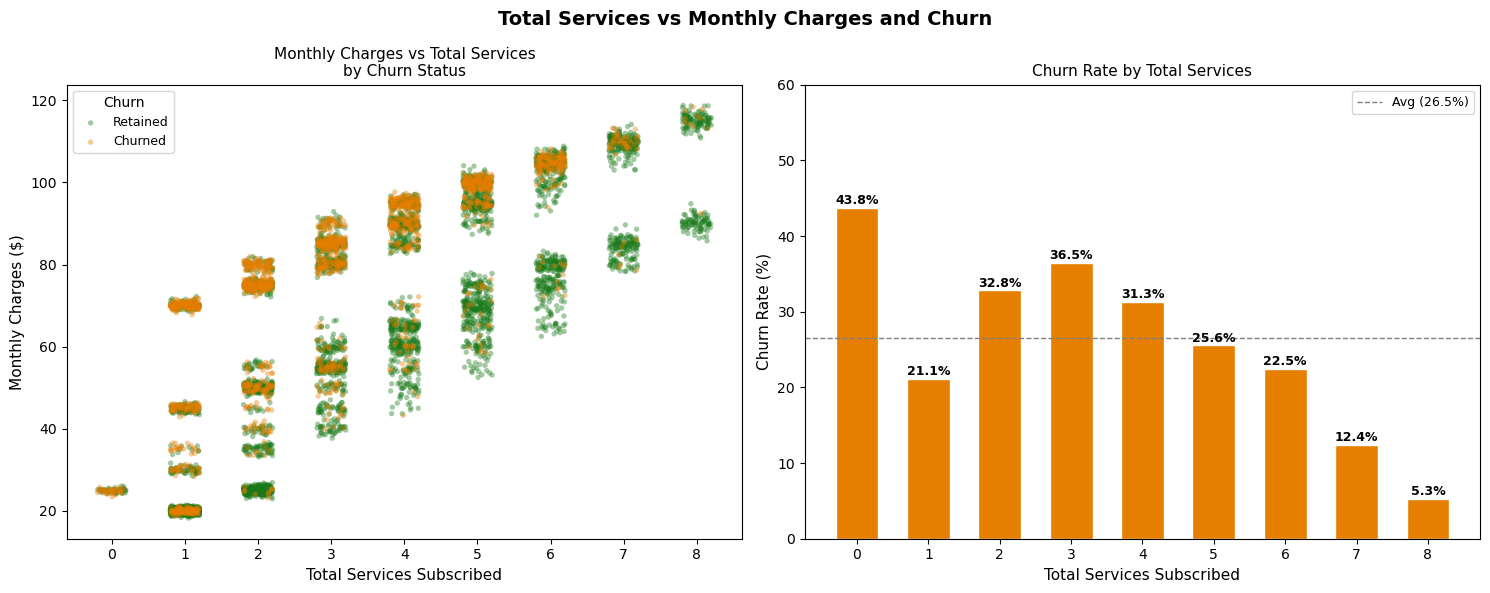

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Total Services vs Monthly Charges and Churn', fontsize=14, fontweight='bold')

#  Scatter monthly charges vs total services, coloured by churn 
for churn_val, label, color in [('No', 'Retained', '#1a7a1a'), ('Yes', 'Churned', '#e67e00')]:
    subset = df[df['Churn'] == churn_val]
    # Small jitter on x so discrete values don't stack into solid columns
    jitter = np.random.RandomState(42).uniform(-0.2, 0.2, len(subset))
    axes[0].scatter(
        subset['totalservices'] + jitter,
        subset['MonthlyCharges'],
        c=color, label=label, alpha=0.4, s=15, edgecolors='none'
    )
axes[0].set_xlabel('Total Services Subscribed', fontsize=11)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=11)
axes[0].set_title('Monthly Charges vs Total Services\nby Churn Status', fontsize=11)
axes[0].set_xticks(range(9))
axes[0].legend(title='Churn', fontsize=9)

#  Bar churn rate by total services 
cr = df.groupby('totalservices')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index(name='ChurnRate')

bars = axes[1].bar(cr['totalservices'], cr['ChurnRate'],
                   color='#e67e00', edgecolor='white', width=0.6)
for bar, rate in zip(bars, cr['ChurnRate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(overall_churn_rate, color='grey', linestyle='--', linewidth=1,
                label=f'Avg ({overall_churn_rate:.1f}%)')
axes[1].set_xlabel('Total Services Subscribed', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_title('Churn Rate by Total Services', fontsize=11)
axes[1].set_xticks(range(9))
axes[1].set_ylim(0, 60)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
# Summary table for totalservices
ts_summary = df.groupby('totalservices')['Churn'].agg(
    Total='count',
    Churned=lambda x: (x == 'Yes').sum(),
    Retained=lambda x: (x == 'No').sum(),
    ChurnRate=lambda x: round((x == 'Yes').mean() * 100, 1)
).reset_index().rename(columns={'ChurnRate': 'Churn Rate (%)'})
ts_summary['% of Dataset'] = (ts_summary['Total'] / ts_summary['Total'].sum() * 100).round(1)
print(ts_summary[['totalservices','Total','% of Dataset','Churned','Retained','Churn Rate (%)']].to_string(index=False))

 totalservices  Total  % of Dataset  Churned  Retained  Churn Rate (%)
             0     80           1.1       35        45            43.8
             1   1701          24.2      359      1342            21.1
             2   1188          16.9      390       798            32.8
             3    965          13.7      352       613            36.5
             4    922          13.1      289       633            31.3
             5    908          12.9      232       676            25.6
             6    676           9.6      152       524            22.5
             7    395           5.6       49       346            12.4
             8    208           3.0       11       197             5.3


Churned customers concentrate at low service count but high monthly charges and the trend seems to be downwards slopping aside from an uptick from 1 to 3. Customers with 8 services chrun at just 5.3% vs 36.5% at 2 services 

# Pre-Processing 

### Useless and Multicolinear Columns 
Customer Id is just an arbitrary identifier, Total Charges presents high multicolinearity risk with various variables (tenure and monthly charge) andn dropping it resolves the 11 NaN rows illustrated earlier. Tenure_bin was for purely visualisation purposes and gender's near zero correlation rate with all other features thus dropping it reduces noise

In [44]:
df_model = df.drop(
    columns=['customerID', 'TotalCharges', 'tenure_bin', 'gender', 'totalservices'],
    errors='ignore'
)

print(f'Shape after dropping: {df_model.shape}')
print(f'Columns remaining:\n{df_model.columns.tolist()}')
print(f'Remaining NaN values: {df_model.isnull().sum().sum()}')

Shape after dropping: (7043, 18)
Columns remaining:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']
Remaining NaN values: 0


In [45]:
df_model.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


### Redundant Service Categories
Several service columns contain a third value ('No phone service' or 'No internet service') that is structurally redundant with the parent feature. For instance, a customer without phone service obviously doesn't have multiple lines. We will thus collapsing to binary Yes/No so that we remove noise without losing information

In [46]:
for col in ['MultipleLines']:
    df_model[col] = df_model[col].replace('No phone service', 'No')

for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_model[col] = df_model[col].replace('No internet service', 'No')

# Verify each should now have exactly 2 unique values
for col in ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']:
    print(f'{col}: {sorted(df_model[col].unique())}')

MultipleLines: ['No', 'Yes']
OnlineSecurity: ['No', 'Yes']
OnlineBackup: ['No', 'Yes']
DeviceProtection: ['No', 'Yes']
TechSupport: ['No', 'Yes']
StreamingTV: ['No', 'Yes']
StreamingMovies: ['No', 'Yes']


In [47]:
df_model.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [48]:
for col in df_model.columns:
    print(f"{col}: {df_model[col].unique()}")

SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
Churn: ['No' 'Yes']


In df_model the only services related values with 3 values are InternetService, Contract and then Payment Method has 4 unique values

In [49]:
df_model.dtypes

SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
Churn                object
dtype: object

### Encoding Categorical features + target value + one-hot encoding multi-category columns

In [50]:
# Binary encoding
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]
binary_map = {'Yes': 1, 'No': 0}
for col in binary_cols:
    df_model[col] = df_model[col].map(binary_map)

# One-hot encoding
df_model = pd.get_dummies(
    df_model,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=True
)

# Cast bool to int
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'Shape after encoding: {df_model.shape}')
print(f'\nFeatures ({df_model.shape[1] - 1} total):')
print([c for c in df_model.columns if c != 'Churn'])

Shape after encoding: (7043, 22)

Features (21 total):
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [51]:
df_model.dtypes

SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
Churn                                      int64
InternetService_Fiber optic                int64
InternetService_No                         int64
Contract_One year                          int64
Contract_Two year                          int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Electr

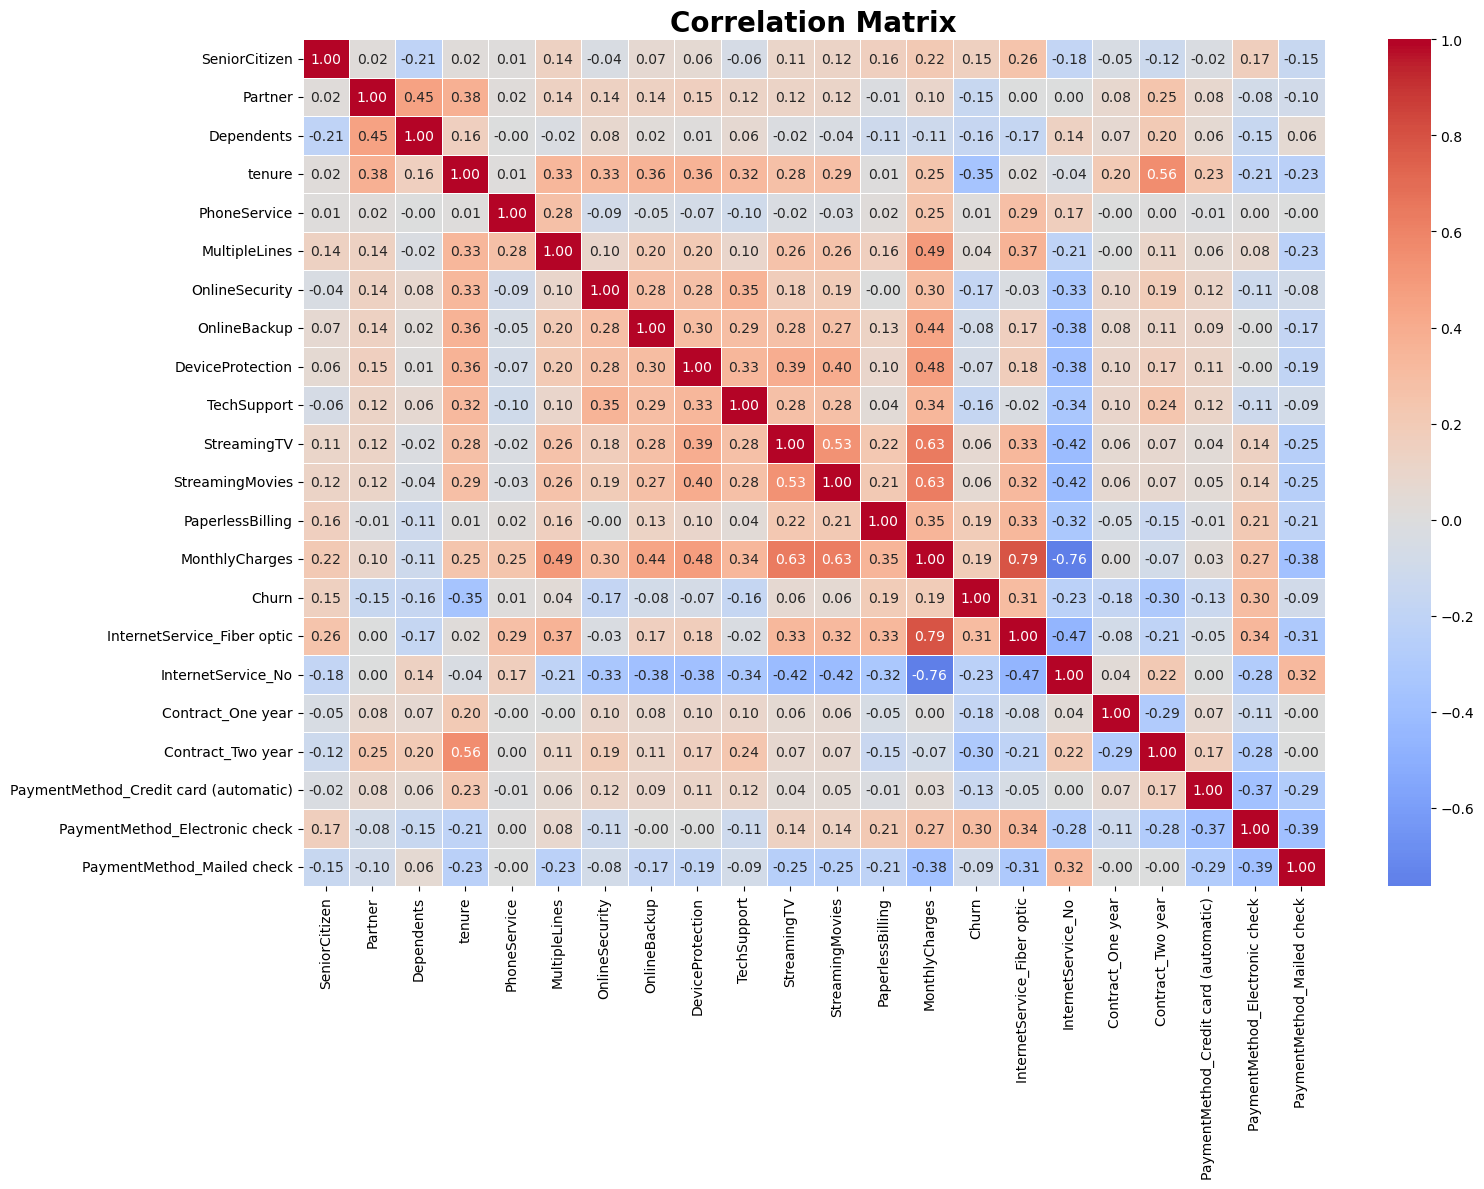

In [52]:
# Correlation matrix 
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_model.corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()


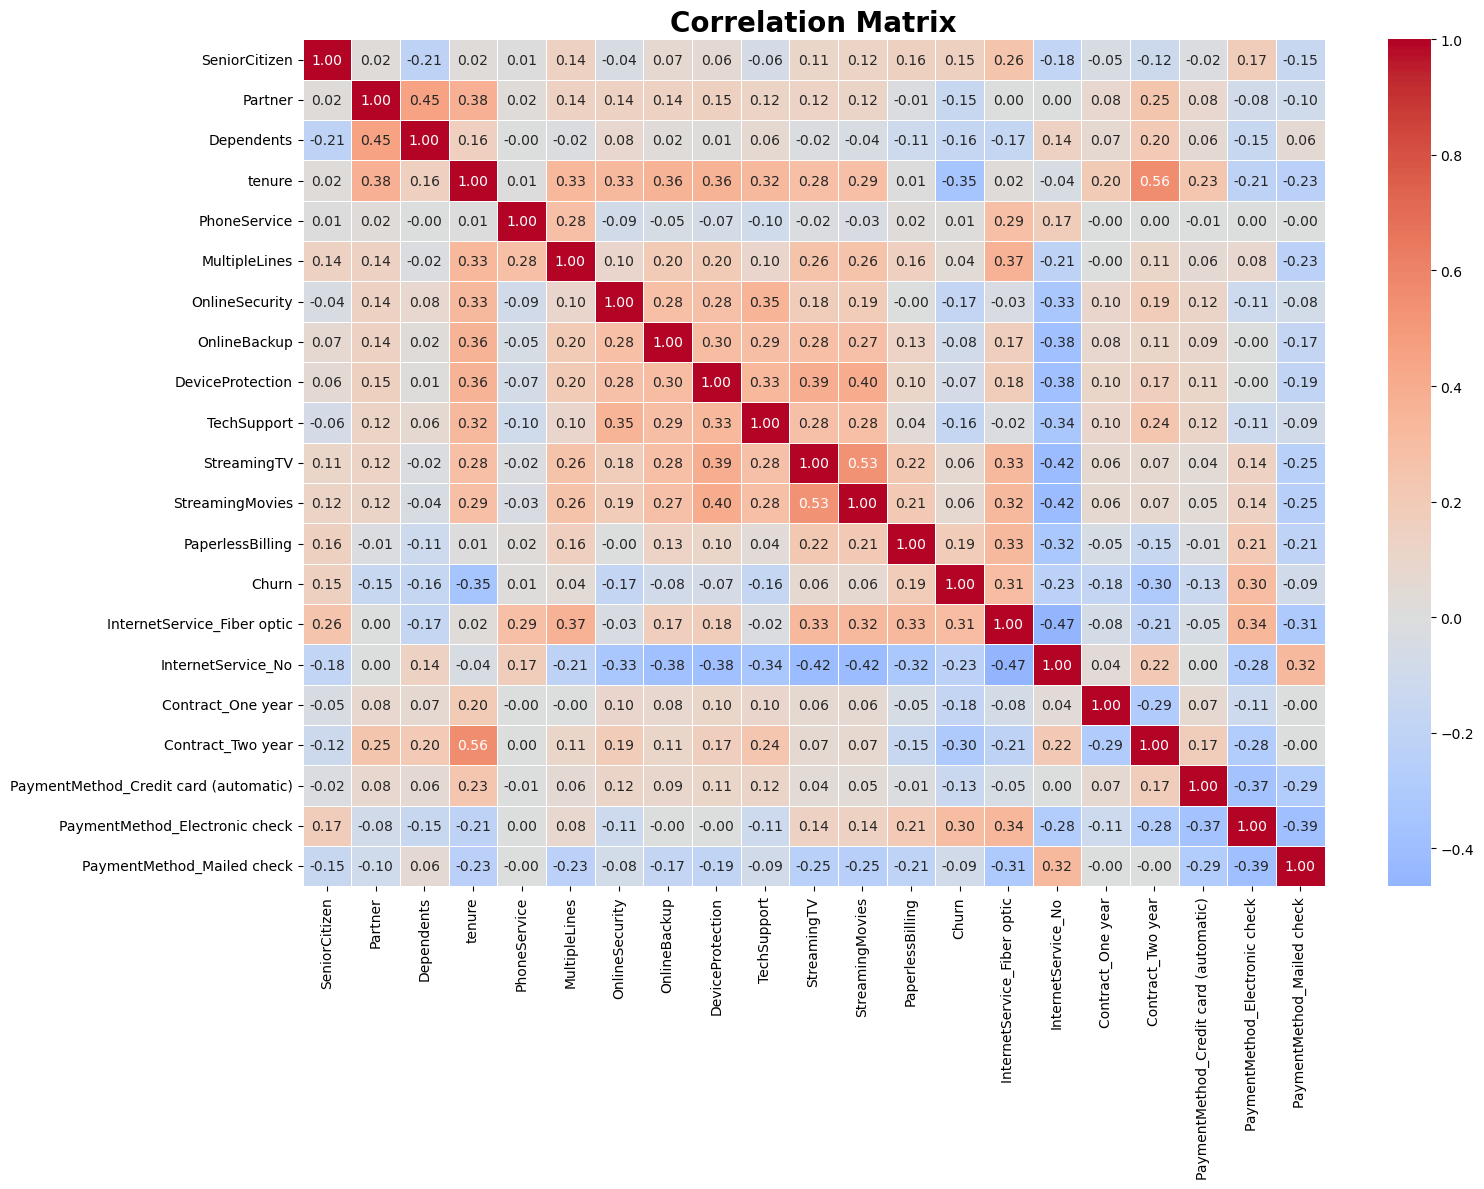

In [53]:
df_model = df_model.drop(columns=['MonthlyCharges'])

# Run Correlation matrix again without MonthlyCharges
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_model.corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()


### Splitting Data: 60, 20,20



In [54]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# First cut: 80% temp / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# Second cut: 75% of temp = 60% total / 25% of temp = 20% total val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

summary = pd.DataFrame({
    'Set'        : ['Train', 'Validation', 'Test'],
    'Samples'    : [len(X_train), len(X_val), len(X_test)],
    '% of Total' : [f'{len(X_train)/len(X)*100:.1f}%',
                    f'{len(X_val)/len(X)*100:.1f}%',
                    f'{len(X_test)/len(X)*100:.1f}%'],
    'Churn Rate' : [f'{y_train.mean()*100:.1f}%',
                    f'{y_val.mean()*100:.1f}%',
                    f'{y_test.mean()*100:.1f}%']
})
print(summary.to_string(index=False))

       Set  Samples % of Total Churn Rate
     Train     4225      60.0%      26.5%
Validation     1409      20.0%      26.5%
      Test     1409      20.0%      26.5%


### Feature Scalling
Applied to three numerical features (tenure). Scaler fited on the trainning set only then those fitted parameters are applied to the validation and test set. 

In [55]:
from sklearn.preprocessing import StandardScaler

num_cols_scale = ['tenure']
scaler = StandardScaler()

X_train_sc = X_train.copy()
X_val_sc   = X_val.copy()
X_test_sc  = X_test.copy()

# Fit on training data only, then apply the same parameters to all splits
X_train_sc[num_cols_scale] = scaler.fit_transform(X_train[num_cols_scale])
X_val_sc[num_cols_scale]   = scaler.transform(X_val[num_cols_scale])
X_test_sc[num_cols_scale]  = scaler.transform(X_test[num_cols_scale])

print('Scaling parameters learned from training set:')
for col, mean, std in zip(num_cols_scale, scaler.mean_, scaler.scale_):
    print(f'  {col}: mean = {mean:.2f}, std = {std:.2f}')

Scaling parameters learned from training set:
  tenure: mean = 32.29, std = 24.67


### Class Imbalance with Smote
Only done on the trainning set 

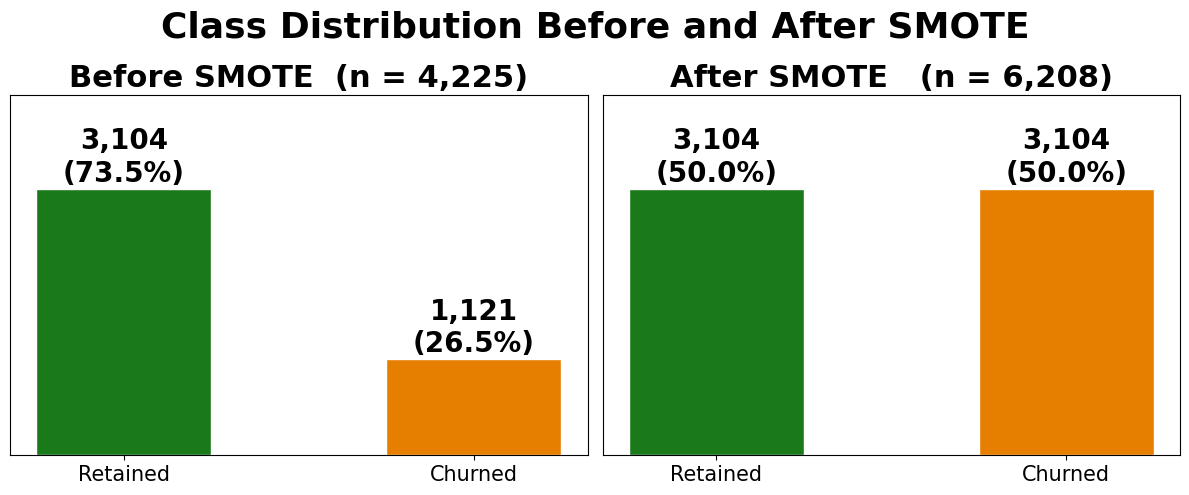

In [56]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution Before and After SMOTE',
             fontsize=26, fontweight='bold')

for ax, (y_data, title) in zip(axes, [
    (y_train,     f'Before SMOTE  (n = {len(y_train):,})'),
    (y_train_res, f'After SMOTE   (n = {len(y_train_res):,})')
]):
    counts = y_data.value_counts().sort_index()
    bars = ax.bar(['Retained', 'Churned'], counts.values,
                  color=['#1a7a1a', '#e67e00'], edgecolor='white', width=0.5)
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 80,
                f'{count:,}\n({count/len(y_data)*100:.1f}%)',
                ha='center', fontsize=20, fontweight='bold')
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_ylim(0, max(counts.values) * 1.35)
    ax.tick_params(axis='both', labelsize=15)
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


In [57]:
print(f'Training set after SMOTE : {X_train_res.shape[0]:,} samples')
print(f'Validation set           : {len(y_val):,} samples')
print(f'Test set                 : {len(y_test):,} samples')


Training set after SMOTE : 6,208 samples
Validation set           : 1,409 samples
Test set                 : 1,409 samples


# MODELLING

In [58]:
#get packages 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from scipy import stats
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve

## Logistic regression

In [59]:
#Train and tune the LogReg
feature_cols = X_train_res.columns.tolist()
X_train_res_ = X_train_res[feature_cols]
X_val_sc_    = X_val_sc[feature_cols] if hasattr(X_val_sc, 'columns') else pd.DataFrame(X_val_sc, columns=X_train_res.columns)[feature_cols]

param_grid = [
    {'penalty': ['l1'], 'C': [0.01, 0.1, 0.02, 0.03, 0.04, 0.5, 1, 1.5, 10, 100], 'solver': ['liblinear', 'saga']},
    {'penalty': ['l2'], 'C': [0.01, 0.1, 0.02, 0.03, 0.04, 1, 10, 100], 'solver': ['liblinear', 'lbfgs', 'saga', 'sag', 'newton-cg']},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10], 'solver': ['saga'], 'l1_ratio': [0.25, 0.5, 0.75]},
]

start = time.time()
grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_res_, y_train_res)

best_params = grid.best_params_
lr_final = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params['solver'],
    random_state=42,
    max_iter=2000
)
lr_final.fit(X_train_res_, y_train_res)
print(f"Total training time: {time.time() - start:.1f} seconds")

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}\n")

val_preds = lr_final.predict(X_val_sc_)
val_proba = lr_final.predict_proba(X_val_sc_)[:, 1]

print("Validation Set Results:")
print(classification_report(y_val, val_preds))
print(f"ROC-AUC: {roc_auc_score(y_val, val_proba):.3f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Total training time: 3.7 seconds

Best parameters: {'C': 0.5, 'penalty': 'l1', 'solver': 'saga'}
Best CV ROC-AUC: 0.867

Validation Set Results:
              precision    recall  f1-score   support

           0       0.90      0.75      0.81      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.830


In [60]:
#Show the features that the model kept  
feature_names = X_train_res_.columns.tolist()
coefficients = lr_final.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

removed = coef_df[coef_df['Coefficient'] == 0]
kept = coef_df[coef_df['Coefficient'] != 0]

print(f"Features kept: {len(kept)}")
print(f"Features removed (sat til 0 af L1): {len(removed)}")
print("\nRemoved features:")
print(removed['Feature'].tolist())
print("\nAll important features:")
print(kept.to_string(index=False))


Features kept: 20
Features removed (sat til 0 af L1): 0

Removed features:
[]

All important features:
                              Feature  Coefficient
                    Contract_Two year    -1.915172
                   InternetService_No    -1.188425
                    Contract_One year    -1.001225
          InternetService_Fiber optic     0.890993
                       OnlineSecurity    -0.736351
                               tenure    -0.614035
                          TechSupport    -0.589642
PaymentMethod_Credit card (automatic)    -0.491908
                           Dependents    -0.477703
                         PhoneService    -0.432797
                         OnlineBackup    -0.300767
                      StreamingMovies     0.230751
           PaymentMethod_Mailed check    -0.219542
                          StreamingTV     0.218492
                        MultipleLines     0.182160
                     PaperlessBilling     0.180957
                        Senior

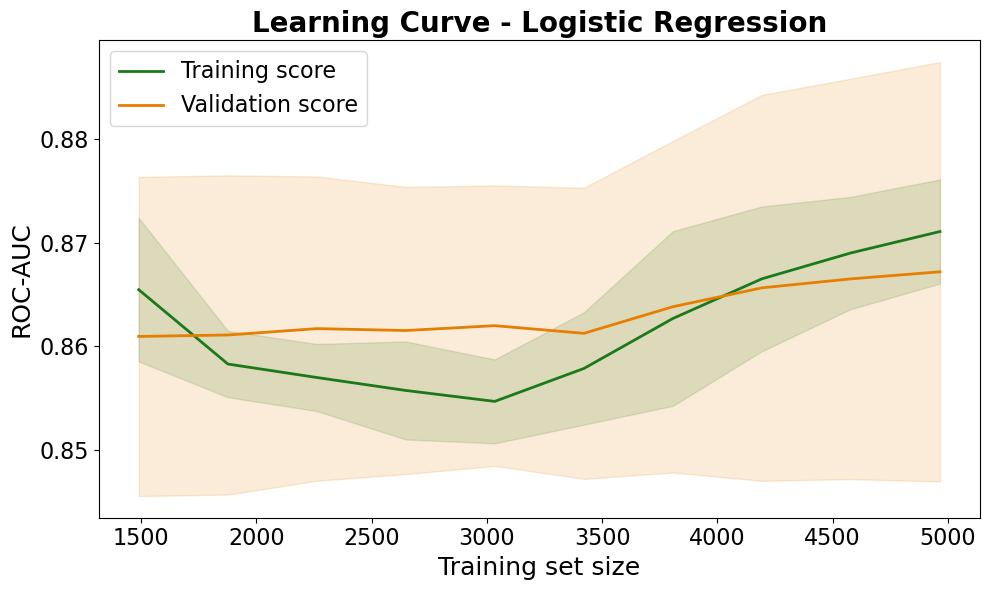

In [61]:
# This is the learning curve for LogReg
train_sizes, train_scores, val_scores = learning_curve(
    lr_final,
    X_train_res[feature_cols],
    y_train_res,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.3, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, label='Training score', color='#1a7a1a', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1a7a1a')
ax.plot(train_sizes, val_mean, label='Validation score', color='#e67e00', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e67e00')
ax.set_xlabel('Training set size', fontsize=18)
ax.set_ylabel('ROC-AUC', fontsize=18)
ax.set_title('Learning Curve - Logistic Regression', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


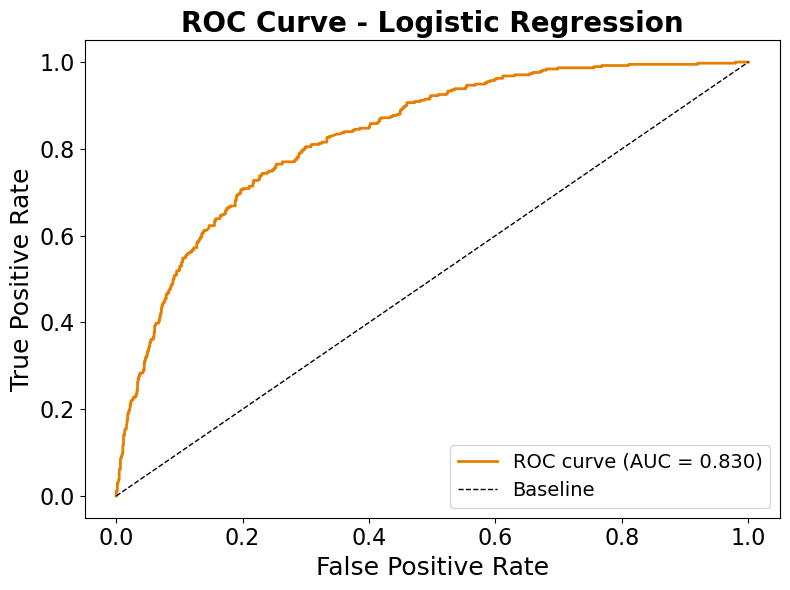

In [62]:
#Plot the model in ROC curve
fpr, tpr, _ = roc_curve(y_val, val_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e67e00', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline')
ax.set_xlabel('False Positive Rate', fontsize=18)
ax.set_ylabel('True Positive Rate', fontsize=18)
ax.set_title('ROC Curve - Logistic Regression', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()


## Random Forest 

## First Random Forest model

In [63]:
# Train and tuning the RF 
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}


start = time.time()
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_res[feature_cols], y_train_res)

best_params_rf = grid_rf.best_params_
rf_final = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    min_samples_split=best_params_rf['min_samples_split'],
    max_features=best_params_rf['max_features'],
    random_state=42
)

rf_final.fit(X_train_res[feature_cols], y_train_res)
print(f"Total training time: {time.time() - start:.1f} seconds")

print(f"\nBest parameters: {grid_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.3f}\n")

val_proba_rf = rf_final.predict_proba(X_val_sc[feature_cols])[:, 1]
val_preds_rf = (val_proba_rf >= 0.50).astype(int)

print("Validation Set Results:")
print(classification_report(y_val, val_preds_rf))
print(f"ROC-AUC: {roc_auc_score(y_val, val_proba_rf):.3f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Total training time: 21.6 seconds

Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV ROC-AUC: 0.921

Validation Set Results:
              precision    recall  f1-score   support

           0       0.87      0.79      0.82      1035
           1       0.53      0.66      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.75      0.76      1409

ROC-AUC: 0.806


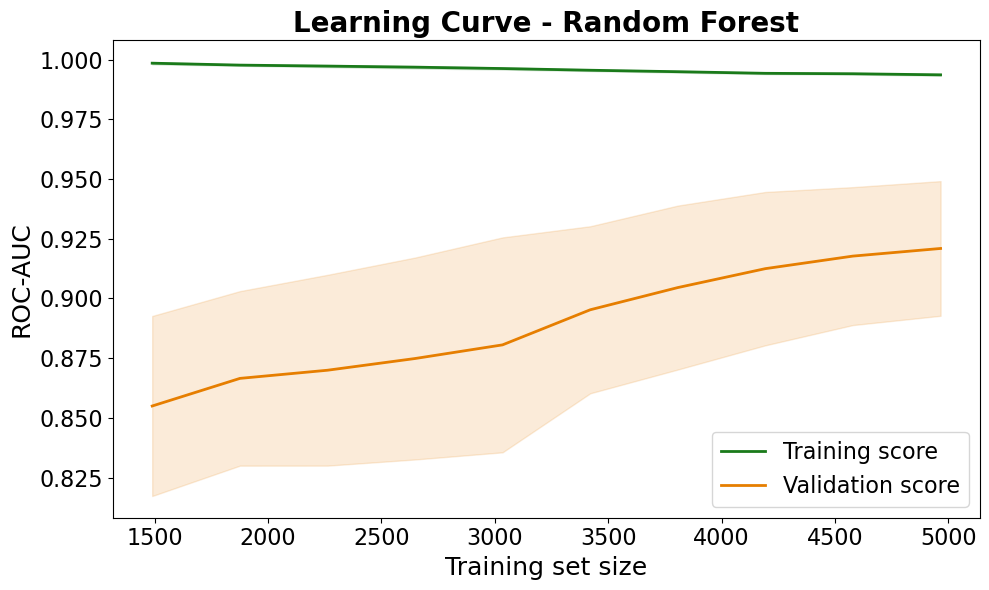

In [64]:
#learning curve FOR 1st RF
train_sizes, train_scores, val_scores = learning_curve(
    rf_final,
    X_train_res[feature_cols],
    y_train_res,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.3, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, label='Training score', color='#1a7a1a', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1a7a1a')
ax.plot(train_sizes, val_mean, label='Validation score', color='#e67e00', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e67e00')
ax.set_xlabel('Training set size', fontsize=18)
ax.set_ylabel('ROC-AUC', fontsize=18)
ax.set_title('Learning Curve - Random Forest', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


## Second attempt at Random Forest

In [65]:
# Train and tuning the RF 
param_grid = {
    'n_estimators': [100, 200, 300, 500, 600],
    'max_depth': [3, 5, 7], 
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2']
}

start = time.time()
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_res[feature_cols], y_train_res)

best_params_rf = grid_rf.best_params_
rf_final = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    min_samples_split=best_params_rf['min_samples_split'],
    min_samples_leaf=best_params_rf['min_samples_leaf'],
    max_features=best_params_rf['max_features'],
    random_state=42
)
rf_final.fit(X_train_res[feature_cols], y_train_res)
print(f"Total training time: {time.time() - start:.1f} seconds")

print(f"\nBest parameters: {grid_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.3f}\n")

val_proba_rf = rf_final.predict_proba(X_val_sc[feature_cols])[:, 1]
val_preds_rf = (val_proba_rf >= 0.50).astype(int)

print("Validation Set Results:")
print(classification_report(y_val, val_preds_rf))
print(f"ROC-AUC: {roc_auc_score(y_val, val_proba_rf):.3f}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Total training time: 59.0 seconds

Best parameters: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.883

Validation Set Results:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.833


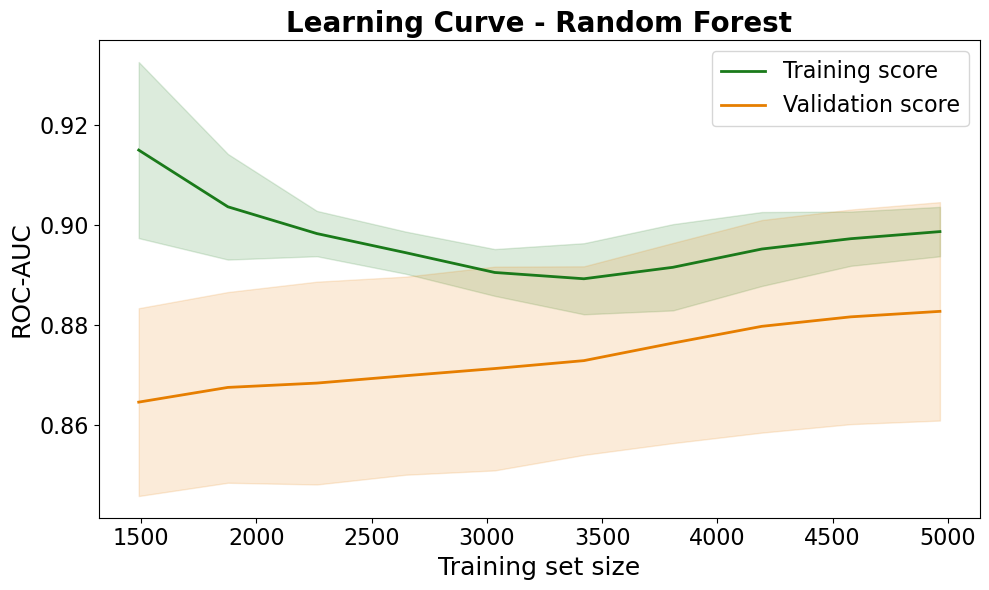

In [66]:
#learning CURVE FOR RF
train_sizes, train_scores, val_scores = learning_curve(
    rf_final,
    X_train_res[feature_cols],
    y_train_res,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.3, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, label='Training score', color='#1a7a1a', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1a7a1a')
ax.plot(train_sizes, val_mean, label='Validation score', color='#e67e00', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e67e00')
ax.set_xlabel('Training set size', fontsize=18)
ax.set_ylabel('ROC-AUC', fontsize=18)
ax.set_title('Learning Curve - Random Forest', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


Still shows some overfitting, but it looks like it could be better with more data 

## XGBoost Boosting

In [67]:
#Fit the XGBoost model 
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 4],
    'min_child_weight': [3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='auc', verbosity=0),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train_res[feature_cols], y_train_res)

print(f"Best parametre: {grid_xgb.best_params_}")
print(f"Best CV ROC-AUC: {grid_xgb.best_score_:.3f}\n")

best_params_xgb = grid_xgb.best_params_
xgb_final = XGBClassifier(
    n_estimators=best_params_xgb['n_estimators'],
    learning_rate=best_params_xgb['learning_rate'],
    max_depth=best_params_xgb['max_depth'],
    min_child_weight=best_params_xgb['min_child_weight'],
    subsample=best_params_xgb['subsample'],
    colsample_bytree=best_params_xgb['colsample_bytree'],
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_final.fit(X_train_res[feature_cols], y_train_res)

val_preds_xgb = xgb_final.predict(X_val_sc[feature_cols])
val_proba_xgb = xgb_final.predict_proba(X_val_sc[feature_cols])[:, 1]

print("Validation Set Results:")
print(classification_report(y_val, val_preds_xgb))
print(f"ROC-AUC: {roc_auc_score(y_val, val_proba_xgb):.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parametre: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 500, 'subsample': 0.8}
Best CV ROC-AUC: 0.897

Validation Set Results:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1035
           1       0.52      0.68      0.59       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.78      0.75      0.76      1409

ROC-AUC: 0.817


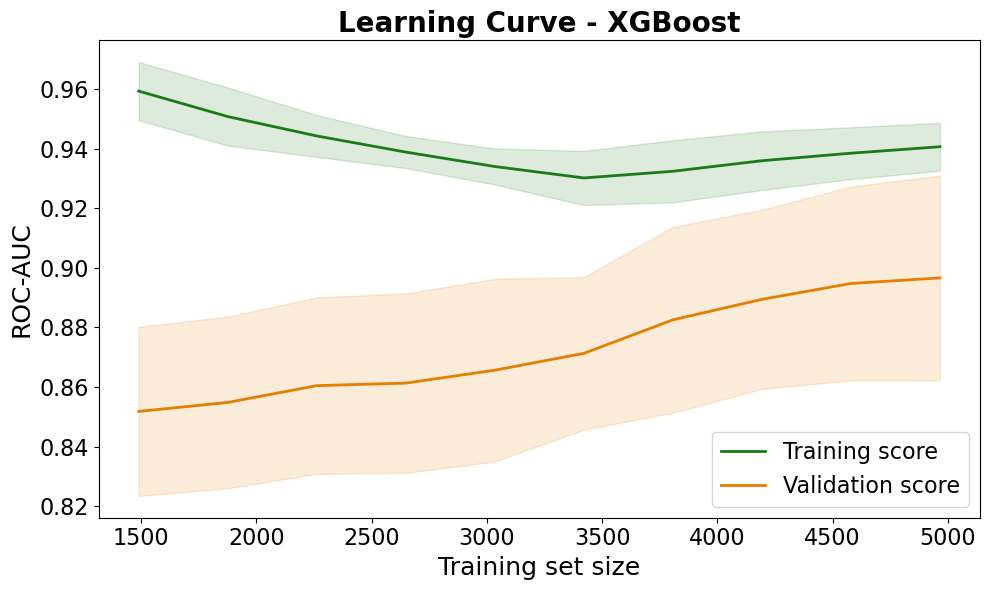

In [68]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_final,
    X_train_res[feature_cols],
    y_train_res,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.3, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, label='Training score', color='#1a7a1a', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1a7a1a')
ax.plot(train_sizes, val_mean, label='Validation score', color='#e67e00', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e67e00')
ax.set_xlabel('Training set size', fontsize=18)
ax.set_ylabel('ROC-AUC', fontsize=18)
ax.set_title('Learning Curve - XGBoost', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


## Try and fix XGBoost overfitting 

In [69]:
# Tune the Boosting model again 
param_grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.02, 0.03],
    'max_depth': [2, 3],
    'min_child_weight': [5, 7, 10],
    'subsample': [0.5, 0.6],
    'colsample_bytree': [0.2, 0.3],
    'reg_alpha': [0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0],
}

start = time.time()
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='auc', verbosity=0),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train_res[feature_cols], y_train_res)

best_params_xgb = grid_xgb.best_params_
xgb_final = XGBClassifier(
    n_estimators=best_params_xgb['n_estimators'],
    learning_rate=best_params_xgb['learning_rate'],
    max_depth=best_params_xgb['max_depth'],
    min_child_weight=best_params_xgb['min_child_weight'],
    subsample=best_params_xgb['subsample'],
    colsample_bytree=best_params_xgb['colsample_bytree'],
    reg_alpha=best_params_xgb['reg_alpha'],
    reg_lambda=best_params_xgb['reg_lambda'],
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_final.fit(X_train_res[feature_cols], y_train_res)
print(f"Total training time: {time.time() - start:.1f} seconds")

print(f"\nBest parameters: {grid_xgb.best_params_}")
print(f"Best CV ROC-AUC: {grid_xgb.best_score_:.3f}\n")

val_proba_xgb = xgb_final.predict_proba(X_val_sc[feature_cols])[:, 1]
val_preds_xgb = (val_proba_xgb >= 0.5).astype(int)

print("Validation Set Results:")
print(classification_report(y_val, val_preds_xgb))
print(f"ROC-AUC: {roc_auc_score(y_val, val_proba_xgb):.3f}")


Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Total training time: 89.0 seconds

Best parameters: {'colsample_bytree': 0.3, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.6}
Best CV ROC-AUC: 0.882

Validation Set Results:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC: 0.831


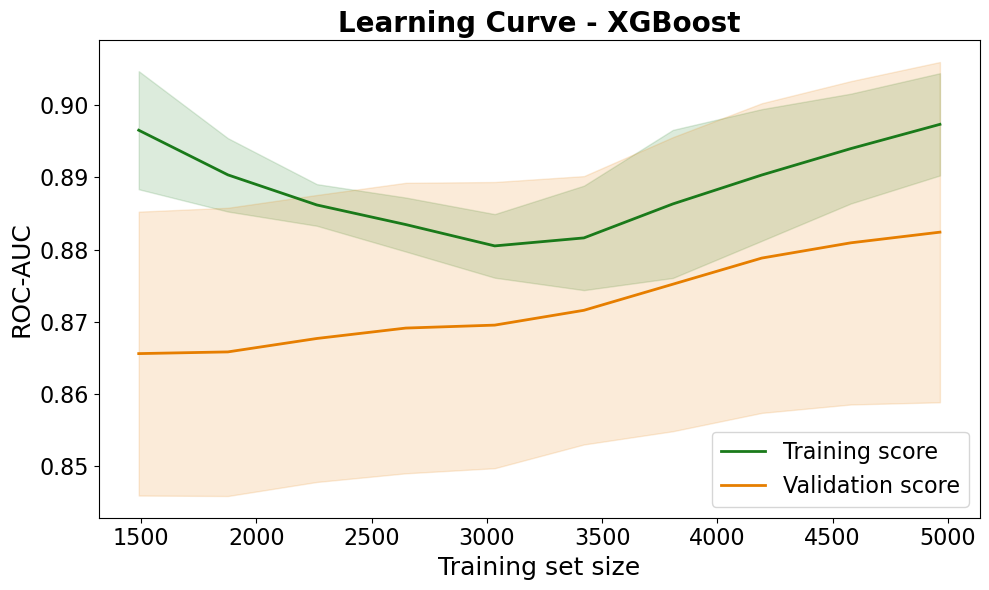

In [70]:
#learning curve for Boosting model 
train_sizes, train_scores, val_scores = learning_curve(
    xgb_final,
    X_train_res[feature_cols],
    y_train_res,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.3, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, label='Training score', color='#1a7a1a', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1a7a1a')
ax.plot(train_sizes, val_mean, label='Validation score', color='#e67e00', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e67e00')
ax.set_xlabel('Training set size', fontsize=18)
ax.set_ylabel('ROC-AUC', fontsize=18)
ax.set_title('Learning Curve - XGBoost', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


## Looks like the overfitting problem is adressed 

## Feature importance

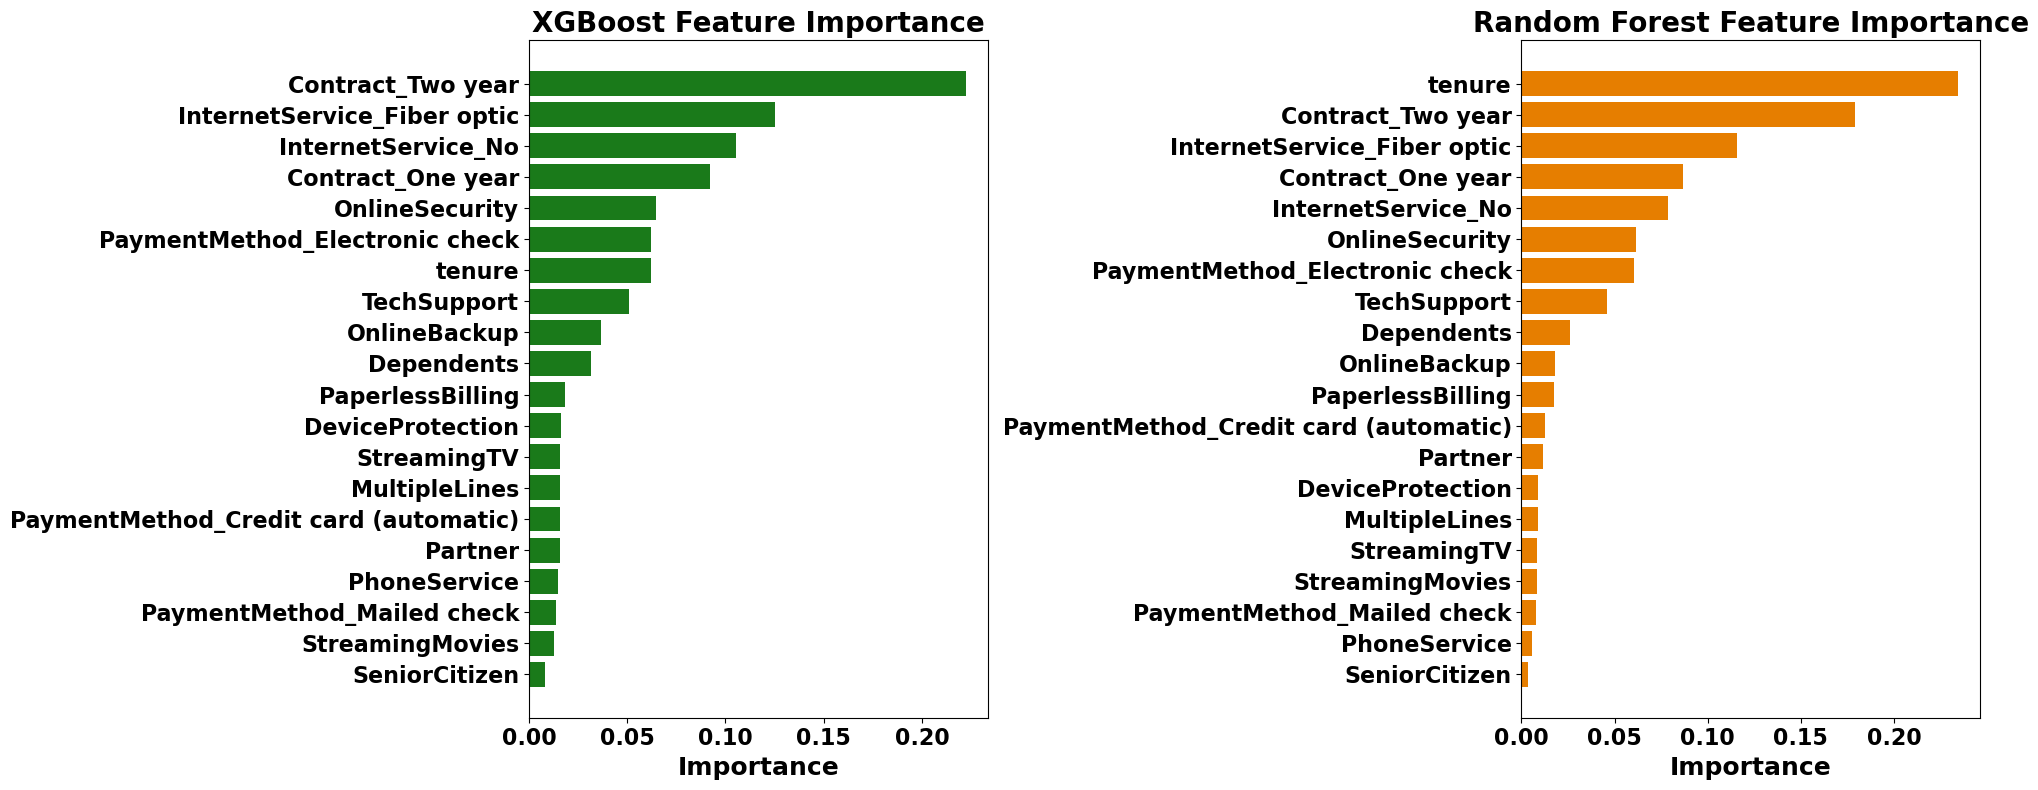

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# XGBoost - left
xgb_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(xgb_imp['Feature'], xgb_imp['Importance'], color='#1a7a1a')
axes[0].set_title('XGBoost Feature Importance', fontsize=20, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=18, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=16)
for label in axes[0].get_yticklabels() + axes[0].get_xticklabels():
    label.set_fontweight('bold')

# Random Forest - right
rf_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(rf_imp['Feature'], rf_imp['Importance'], color='#e67e00')
axes[1].set_title('Random Forest Feature Importance', fontsize=20, fontweight='bold')
axes[1].set_xlabel('Importance', fontsize=18, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=16)
for label in axes[1].get_yticklabels() + axes[1].get_xticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()


# Model results together


In [72]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Validation Set Results")

val_models = {
    'Logistic Regression': val_proba,
    'Random Forest':       val_proba_rf,
    'XGBoost':             val_proba_xgb,
}

for name, proba in val_models.items():
    preds = (proba >= 0.5).astype(int)
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_val, preds))
    print(f"ROC-AUC: {roc_auc_score(y_val, proba):.3f}")


Validation Set Results

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.75      0.81      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.830

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.833

XGBoost
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0

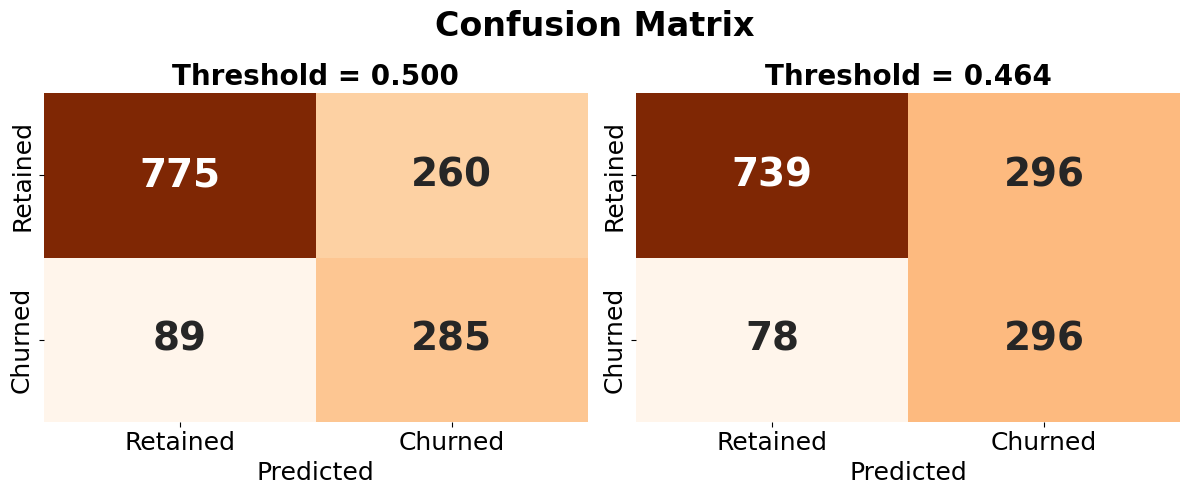

Default threshold: 0.500
Optimised threshold (precision = 0.50): 0.464


In [73]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba_rf)
diffs = abs(precisions[:-1] - 0.50)
idx = diffs.argmin()
best_threshold = thresholds[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix', fontsize=24, fontweight='bold')

for ax, threshold in zip(axes, [0.5, best_threshold]):
    preds = (val_proba_rf >= threshold).astype(int)
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                cbar=False, annot_kws={'size': 28, 'weight': 'bold'},
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'Threshold = {threshold:.3f}', fontsize=20, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('Predicted', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

plt.tight_layout()
plt.show()

print(f"Default threshold: 0.500")
print(f"Optimised threshold (precision = 0.50): {best_threshold:.3f}")


In [74]:
test_proba_lr  = lr_final.predict_proba(X_test_sc[feature_cols])[:, 1]
test_proba_rf  = rf_final.predict_proba(X_test_sc[feature_cols])[:, 1]
test_proba_xgb = xgb_final.predict_proba(X_test_sc[feature_cols])[:, 1]

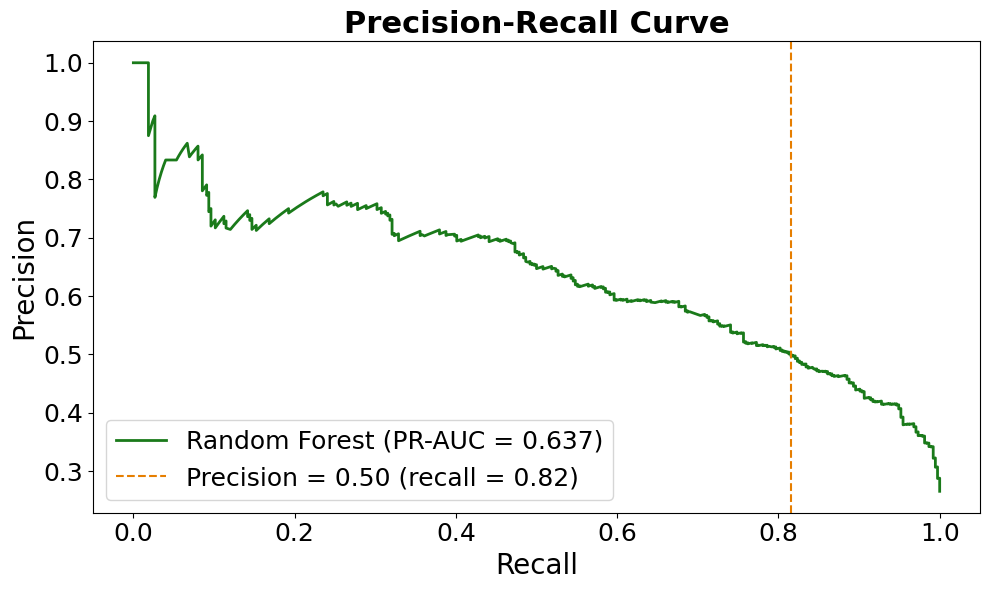

In [75]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba_rf)
pr_auc = auc(recalls, precisions)

# Find threshold hvor precision = 0.5
diffs = abs(precisions[:-1] - 0.50)
idx = diffs.argmin()
best_recall = recalls[idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recalls, precisions, linewidth=2, color='#1a7a1a', label=f'Random Forest (PR-AUC = {pr_auc:.3f})')
ax.axvline(x=best_recall, color='#e67e00', linewidth=1.5, linestyle='--', label=f'Precision = 0.50 (recall = {best_recall:.2f})')
ax.set_xlabel('Recall', fontsize=20)
ax.set_ylabel('Precision', fontsize=20)
ax.set_title('Precision-Recall Curve', fontsize=22, fontweight='bold')
ax.legend(fontsize=18)
ax.tick_params(axis='both', labelsize=18)
plt.tight_layout()
plt.show()

In [76]:
#Testing

print("Test Set Result (threshold = 0.5)")

test_models = {
    'Logistic Regression': test_proba_lr,
    'Random Forest':       test_proba_rf,
    'XGBoost':             test_proba_xgb,
}

for name, proba in test_models.items():
    preds = (proba >= 0.5).astype(int)
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, preds))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")

Test Set Result (threshold = 0.5)

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409

ROC-AUC: 0.834

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.841

XGBoost
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       

In [ ]:
import time

#  Logisitc Regression
start = time.time()
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    [
        {'penalty': ['l1'], 'C': [0.01, 0.1, 0.02, 0.03, 0.04, 0.5, 1, 1.5, 10, 100], 'solver': ['liblinear', 'saga']},
        {'penalty': ['l2'], 'C': [0.01, 0.1, 0.02, 0.03, 0.04, 1, 10, 100], 'solver': ['liblinear', 'lbfgs', 'saga', 'sag', 'newton-cg']},
        {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10], 'solver': ['saga'], 'l1_ratio': [0.5]},
    ],
    cv=5, scoring='roc_auc', n_jobs=-1
)
grid_lr.fit(X_train_res[feature_cols], y_train_res)
lr_train_time = time.time() - start

start = time.time()
lr_final.predict_proba(X_test_sc[feature_cols])
lr_predict_time = time.time() - start

# Random Forest  
start = time.time()
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators': [100, 200, 300, 500, 600],
        'max_depth': [3, 5, 7],
        'min_samples_split': [10, 20, 30],
        'min_samples_leaf': [5, 10],
        'max_features': ['sqrt', 'log2']
    },
    cv=5, scoring='roc_auc', n_jobs=-1
)
grid_rf.fit(X_train_res[feature_cols], y_train_res)
rf_train_time = time.time() - start

start = time.time()
rf_final.predict_proba(X_test_sc[feature_cols])
rf_predict_time = time.time() - start

# XGBOOST 
start = time.time()
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='auc', verbosity=0),
    {
        'n_estimators': [300, 500],
        'learning_rate': [0.01, 0.02, 0.03],
        'max_depth': [2, 3],
        'min_child_weight': [5, 7, 10],
        'subsample': [0.5, 0.6],
        'colsample_bytree': [0.2, 0.3],
        'reg_alpha': [0.1, 0.5, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0],
    },
    cv=5, scoring='roc_auc', n_jobs=-1
)
grid_xgb.fit(X_train_res[feature_cols], y_train_res)
xgb_train_time = time.time() - start

start = time.time()
xgb_final.predict_proba(X_test_sc[feature_cols])
xgb_predict_time = time.time() - start

#Results printing
print(f"\n{'Model':<22} {'GridSearch Time (s)':>20} {'Predict Time (s)':>17}")
print("-" * 62)
print(f"{'Logistic Regression':<22} {lr_train_time:>20.1f} {lr_predict_time:>17.4f}")
print(f"{'Random Forest':<22} {rf_train_time:>20.1f} {rf_predict_time:>17.4f}")
print(f"{'XGBoost':<22} {xgb_train_time:>20.1f} {xgb_predict_time:>17.4f}")

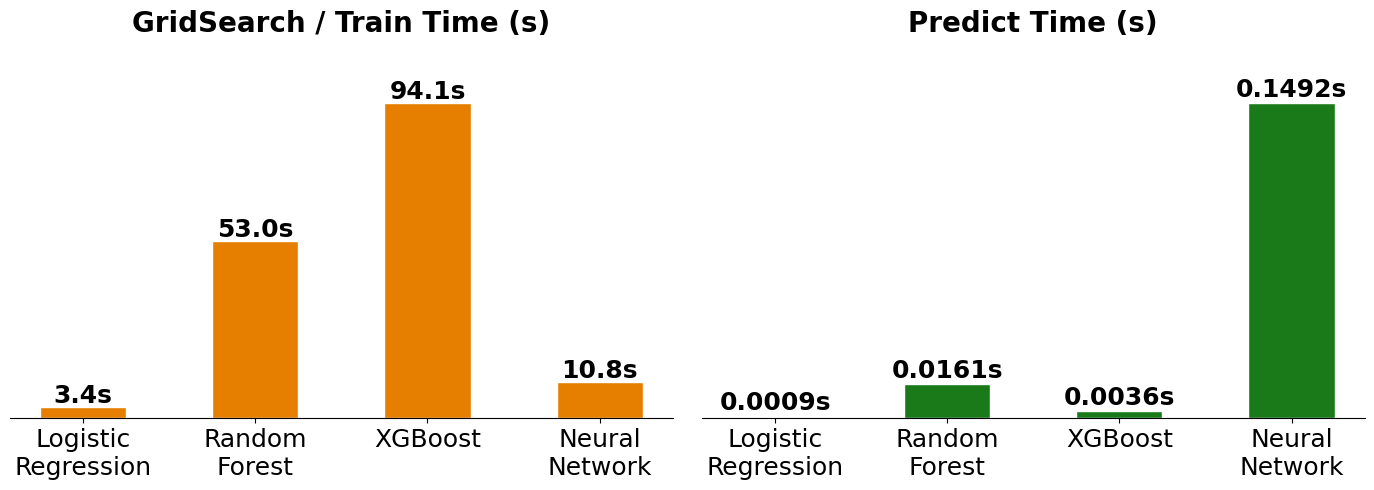

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'Neural\nNetwork']
gridsearch_times = [3.4, 53.0, 94.1, 10.8]
predict_times    = [0.0009, 0.0161, 0.0036, 0.1492]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(models))

# GridSearch / Train Time 
bars1 = axes[0].bar(x, gridsearch_times, color='#e67e00', width=0.5, edgecolor='white')
axes[0].set_title('GridSearch / Train Time (s)', fontsize=20, fontweight='bold', pad=40)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=18)
axes[0].set_yticks([])
axes[0].spines[['top', 'right', 'left']].set_visible(False)
for bar, val in zip(bars1, gridsearch_times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.2,
                 f'{val:.1f}s', ha='center', fontsize=18, fontweight='bold')

#  Predict Time 
bars2 = axes[1].bar(x, predict_times, color='#1a7a1a', width=0.5, edgecolor='white')
axes[1].set_title('Predict Time (s)', fontsize=20, fontweight='bold', pad=40)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=18)
axes[1].set_yticks([])
axes[1].spines[['top', 'right', 'left']].set_visible(False)
for bar, val in zip(bars2, predict_times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.4f}s', ha='center', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

# All NN CODE WAS RAN IN GOOGLE COLAB 

In [ ]:
#from google.colab import files
#import pickle

#uploaded = files.upload()

#with open('train_val_test_data.pkl', 'rb') as f:
#    data = pickle.load(f)

#X_train_res = data['X_train_res']
#y_train_res = data['y_train_res']
#X_val_sc = data['X_val_sc']
#y_val = data['y_val']
#X_test_sc = data['X_test_sc']
#y_test = data['y_test']
#feature_cols = data['feature_cols']

#print("Data loaded succesfully")

ModuleNotFoundError: No module named 'google'

In [ ]:
#

#tf.random.set_seed(42)
#np.random.seed(42)

#model = keras.Sequential([
#    keras.layers.Dense(32, activation='relu', 
#                       kernel_regularizer=keras.regularizers.l2(0.01),
#                       input_shape=(X_train_res.shape[1],)),
#    keras.layers.Dropout(0.4),
#    keras.layers.Dense(16, activation='relu',
#                       kernel_regularizer=keras.regularizers.l2(0.01)),
#    keras.layers.Dropout(0.4),
#    keras.layers.Dense(1, activation='sigmoid')
#])

#model.compile(
#    optimizer=keras.optimizers.Adam(learning_rate=0.001),
#    loss='binary_crossentropy',
#    metrics=['AUC']
#)

#early_stopping = keras.callbacks.EarlyStopping(
#    monitor='val_AUC',
#    patience=10,
#    restore_best_weights=True,
#    mode='max'
#)

#start = time.time()
#history = model.fit(
#    X_train_res, y_train_res,
#    validation_data=(X_val_sc, y_val),
#    epochs=100,
#    batch_size=32,
#    callbacks=[early_stopping],
#    verbose=0
#)
#nn_train_time = time.time() - start

#train_auc = history.history['AUC']
#val_auc = history.history['val_AUC']
#epochs = range(len(train_auc))

#fig, ax = plt.subplots(figsize=(10, 6))
#ax.plot(epochs, train_auc, label='Training score', color='#1a7a1a', linewidth=2)
#ax.plot(epochs, val_auc, label='Validation score', color='#e67e00', linewidth=2)
#ax.set_xlabel('Epochs', fontsize=18)
#ax.set_ylabel('ROC-AUC', fontsize=18)
#ax.set_title('Learning Curve - Neural Network', fontsize=20, fontweight='bold')
#ax.tick_params(axis='both', labelsize=16)
#ax.legend(fontsize=16)
#plt.tight_layout()
#plt.show()

#val_proba_nn = model.predict(X_val_sc).flatten()
#val_preds_nn = (val_proba_nn >= 0.5).astype(int)

#print("Validation Set Results(threshold = 0.5)")
#print(f"\n{'='*50}")
#print("Neural Network")
#print('='*50)
#print(classification_report(y_val, val_preds_nn))
#print(f"ROC-AUC: {roc_auc_score(y_val, val_proba_nn):.3f}")

#start = time.time()
#test_proba_nn = model.predict(X_test_sc, verbose=0).flatten()
#nn_predict_time = time.time() - start

#test_preds_nn = (test_proba_nn >= 0.5).astype(int)

#print("\nTest Set Results (threshold = 0.5)")
#print(f"\n{'='*50}")
#print("Neural Network")
#print('='*50)
#print(classification_report(y_test, test_preds_nn))
#print(f"ROC-AUC: {roc_auc_score(y_test, test_proba_nn):.3f}")

#print(f"\n{'Model':<22} {'Train Time (s)':>15} {'Predict Time (s)':>17}")
#print("-" * 57)
#print(f"{'Neural Network':<22} {nn_train_time:>15.1f} {nn_predict_time:>17.4f}")